# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 43     |  |
| :-------------|:-------------|
| Christiaan Paardenkooper | 6453902 |
| Niels van Meurs | 6190243 |
| Jelle Kooloos | 6532241 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['kris', 'niels','jelle']

## Opdracht 1: Planning.

| Planning Groep: 43     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie mettingen | 11:30 |
| testen meet opstelling | 12:00 |
| iteratie 1 | 15:00 |
| itereren | 17:00 |
| groep aanwezig 1| 10:45|
| groep aanwezig 2| 13:45|
| Pauze 1| 12:45-13:45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [43]<br>
<img src="kalibratie.jpg" width="400">

0.0345866701291786 -0.6979806784196922


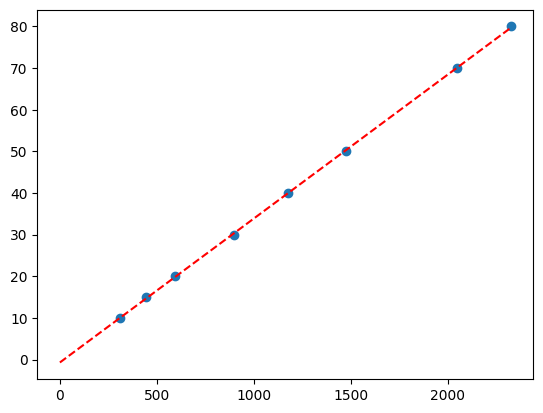

In [3]:
afstand = (310, 445, 593, 898, 1178, 1475, 2046, 2324)
mettingen = (10, 15, 20, 30, 40, 50, 70, 80) #cm

def kalibratie(afstand, a, b):
    return afstand*a + b
val, cov = curve_fit(kalibratie, afstand, mettingen)
a, b = val[0], val[1]
t = np.linspace(0, afstand[-1], 10000)
plt.scatter(afstand, mettingen)
plt.plot(t, kalibratie(t, a,b), 'r--')
print(a,b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  46.02
1   0  30   0  20  46.70
2  40   0  30   0  44.62
3  30   0  20   0  45.10
4  10   0   0  10  21.34


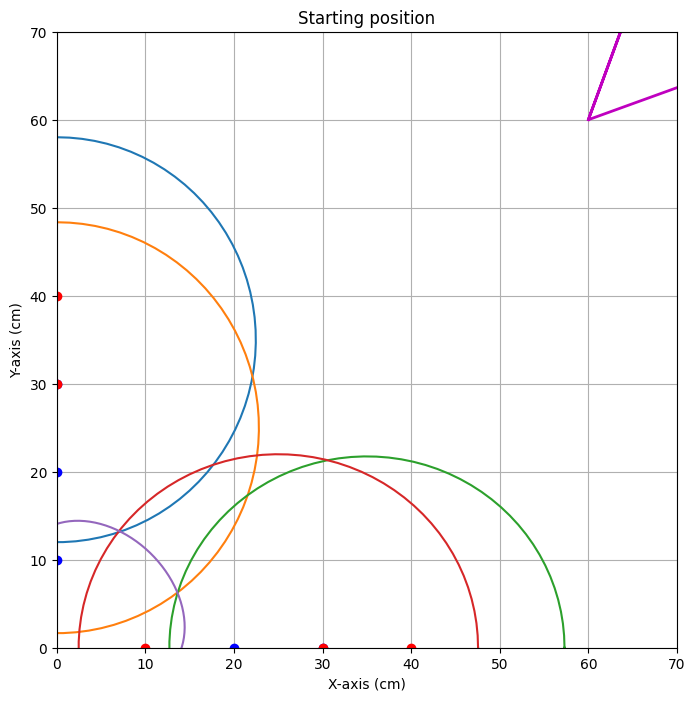


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=105.571


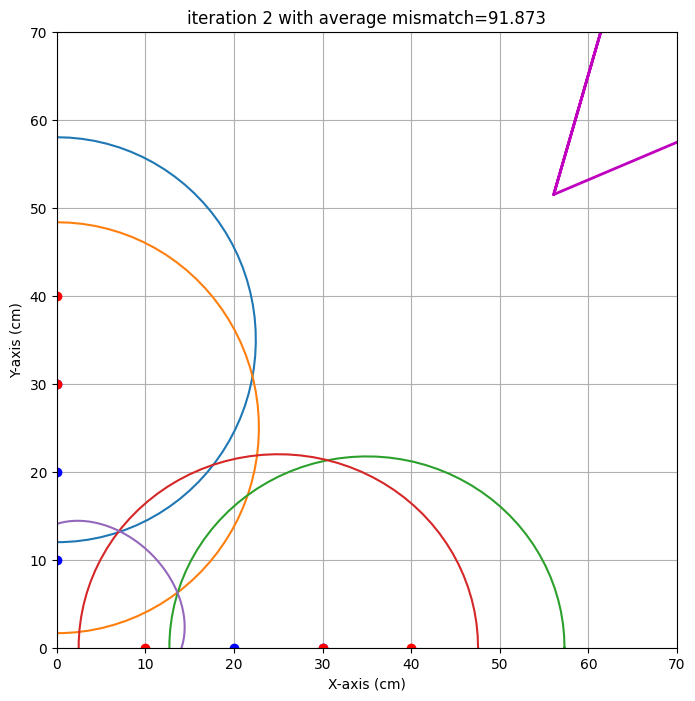

end iteration 2 with average mismatch=91.873


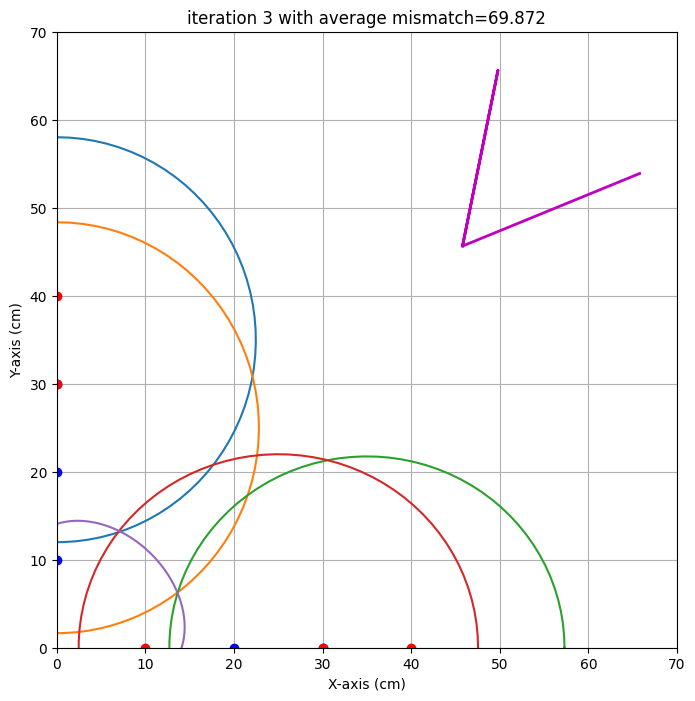

end iteration 3 with average mismatch=69.872


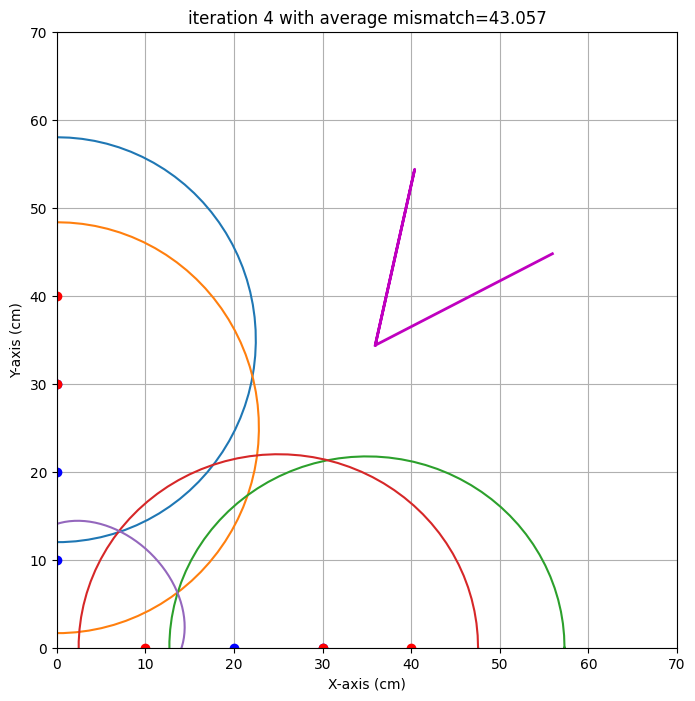

end iteration 4 with average mismatch=43.057


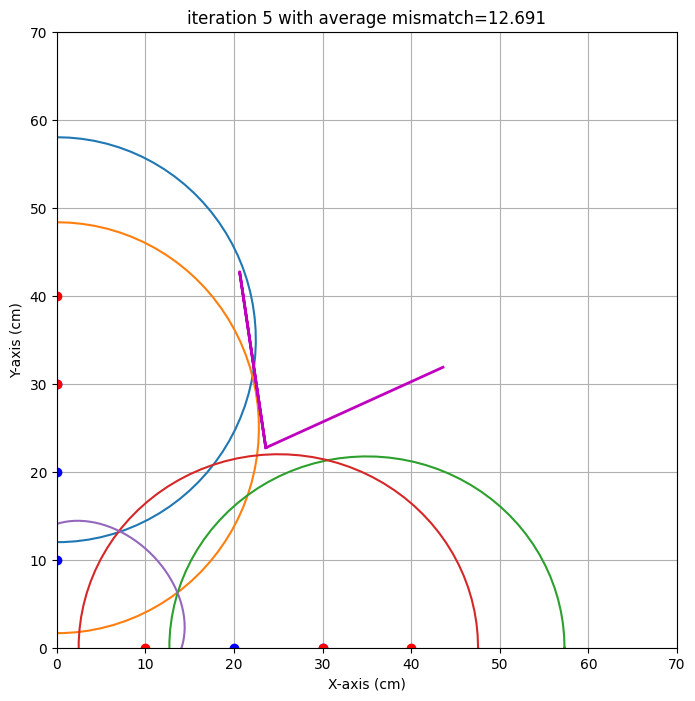

end iteration 5 with average mismatch=12.691


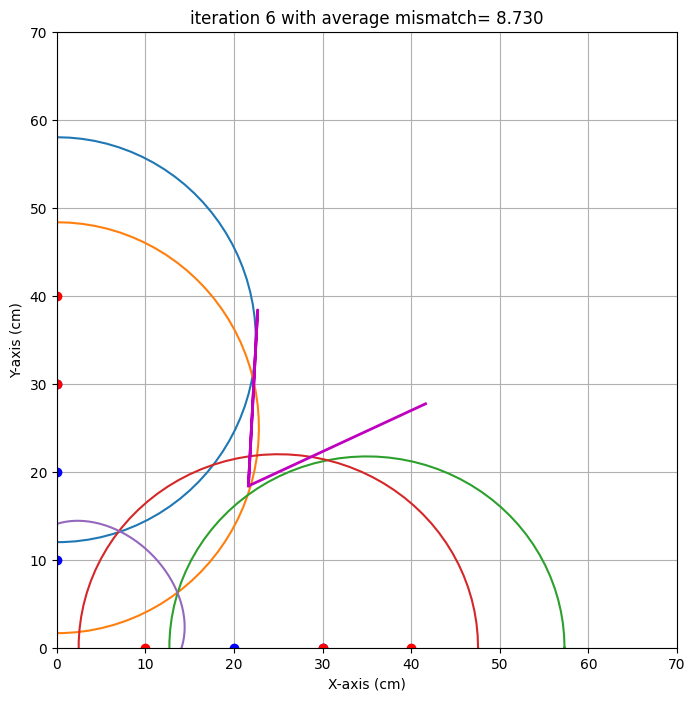

end iteration 6 with average mismatch= 8.730
end iteration 7 with average mismatch= 8.478
end iteration 8 with average mismatch= 8.475
end iteration 9 with average mismatch= 8.460
end iteration 10 with average mismatch= 8.452
end iteration 11 with average mismatch= 8.452
end iteration 12 with average mismatch= 8.291
end iteration 13 with average mismatch= 8.291
end iteration 14 with average mismatch= 8.291
end iteration 15 with average mismatch= 8.291
end iteration 16 with average mismatch= 8.291
end iteration 17 with average mismatch= 8.291
end iteration 18 with average mismatch= 8.285
end iteration 19 with average mismatch= 8.217
end iteration 20 with average mismatch= 8.217
end iteration 21 with average mismatch= 8.217
end iteration 22 with average mismatch= 8.204
end iteration 23 with average mismatch= 8.204
end iteration 24 with average mismatch= 8.204
end iteration 25 with average mismatch= 8.173
end iteration 26 with average mismatch= 8.173
end iteration 27 with average mismatch

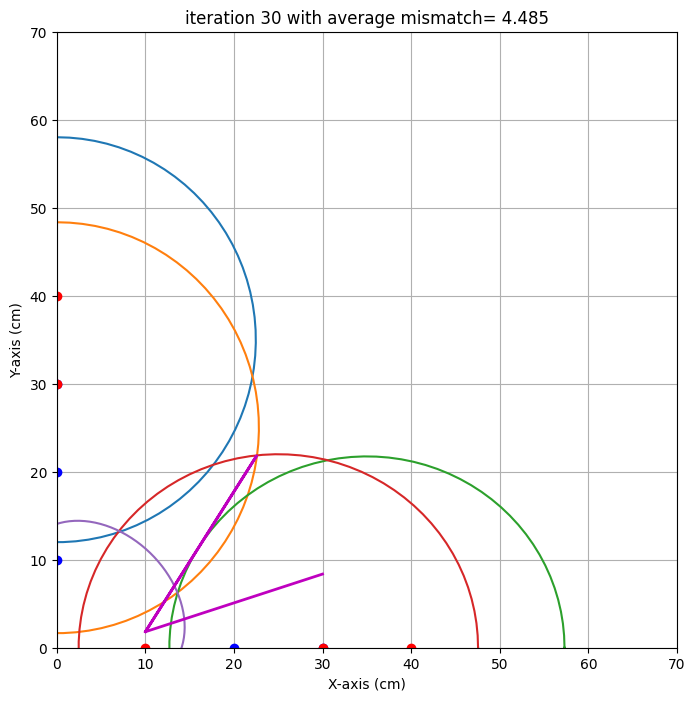

end iteration 30 with average mismatch= 4.485
###############################################################################
end of iteration  30
Best alpha=  18.14 with uncertainty=  14.39
Best beta =  32.13 with uncertainty=  10.87
Best x0   =   9.99 with uncertainty=   3.65
Best y0   =   1.81 with uncertainty=   5.00
###############################################################################


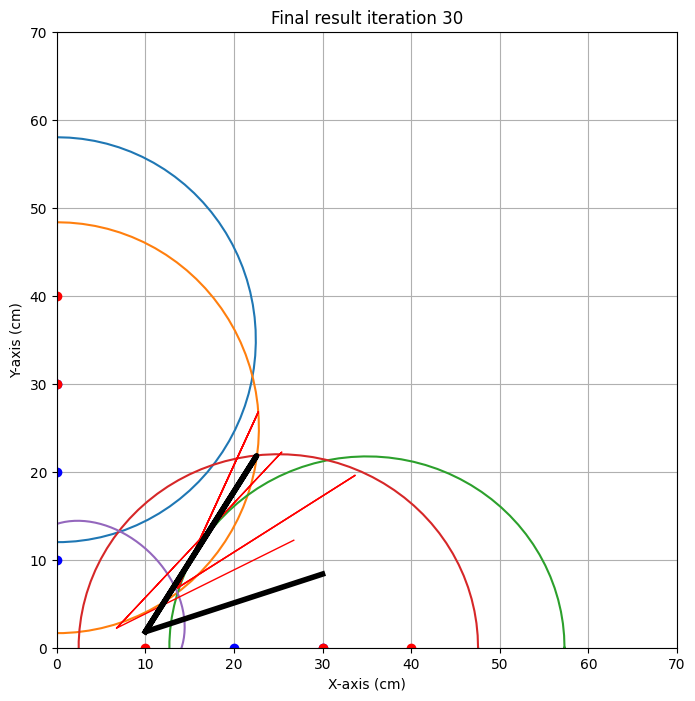

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30, 46.02],
    [0,30,0,20, 46.70],
    #[0,10,0,20, 139.4], 
    [40,0,30,0, 44.62], 
    [30,0,20,0, 45.10],
    #[10,0,20,0, 53.13],
    [10,0,0,10, 21.34]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 10.0 cm met een standaardafwijking van 3.7 cm 
y0: 1.8 cm met een standaardafwijking van 5.0 cm 
alpha: 18.1 graden met een standaardafwijking van 14.4 graad 
beta: 32.1 graden met een standaardafwijking van 10.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Christiaan]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="kris.jpeg" width="400">

<img src="iteratie_1.jpeg" width="400">

#### algoritme [Niels]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="niels.jpeg" width="400">

#### algoritme [Jelle]
Voeg een foto in van het algoritme van het derde groepslid
<img src="jelle.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  49,
           'y0': 49,
           'alpha' : 30,
           'beta' : 180,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'kris' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 0, 45, 170],
    [45,0 , 35,0, 69.58],
    [45,0, 55, 0, 99.3],
    [0,45, 0,35,98.2],
    [0,45, 0,35, 89.2]
    ]),
       'niels' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0, 162]
    [0, 50, 0, 60, 68.8], 
    [0, 40, 0, 50, 94],
    [35, 0, 40,0, 98],
    [20,0, 25,0, 97],
    [50,0,40,0,98.6]   
    ]),
       'jelle' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0, 34,0, 179],
    #[0,34, 0, 40, 140],
    [0,50,0,56,62],
    [0,60, 0,56, 63],
    [50,0,59,0, 108],
    [40,0,64,0, 148]

    ])
      }

## Opdracht 7: Evaluatie.

kris
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  45   0  35   0  69.58
1  45   0  55   0  99.30
2   0  45   0  35  98.20
3   0  45   0  35  89.20


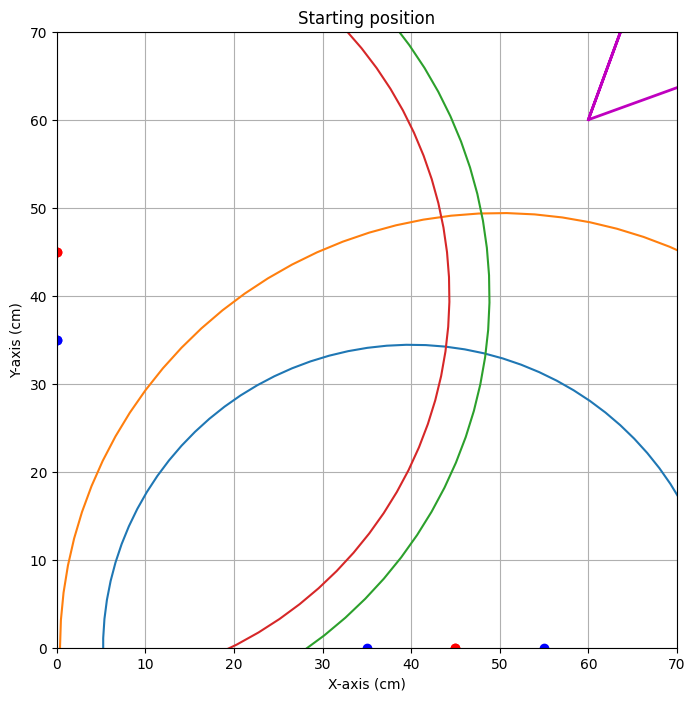


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.373


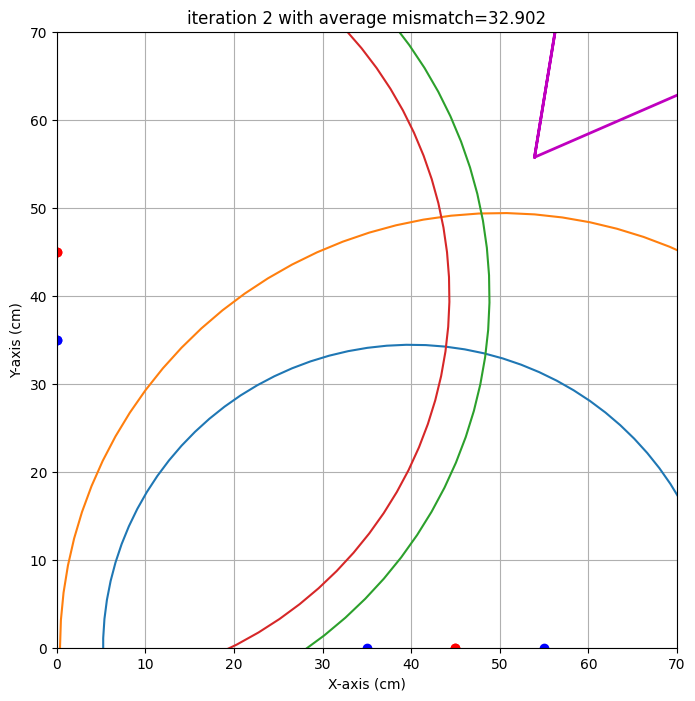

end iteration 2 with average mismatch=32.902


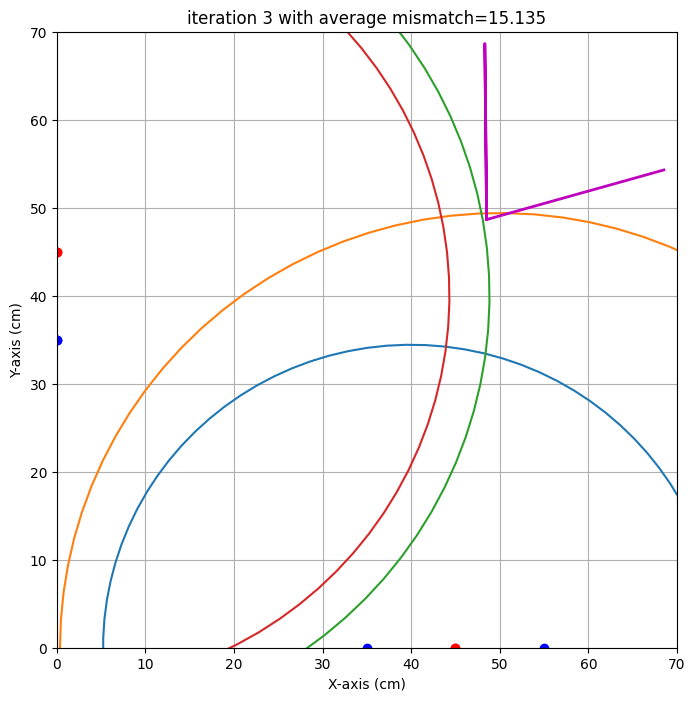

end iteration 3 with average mismatch=15.135


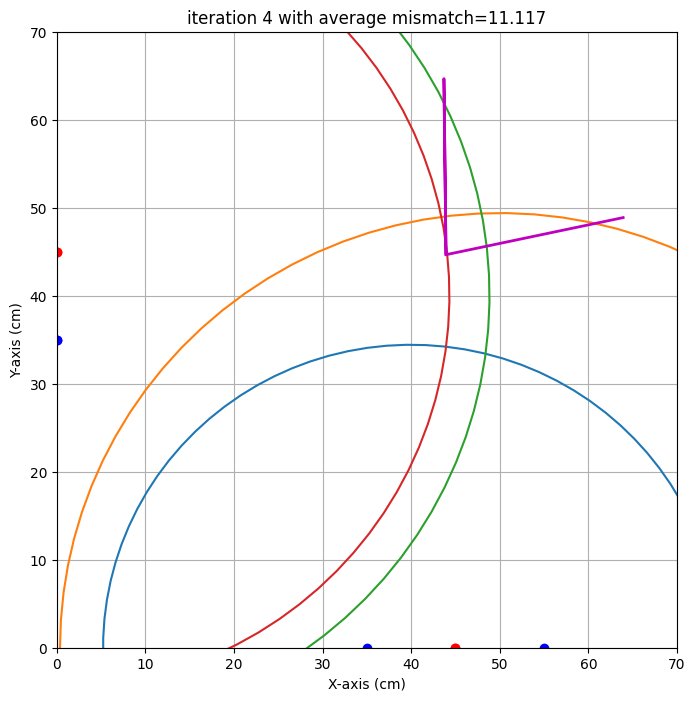

end iteration 4 with average mismatch=11.117


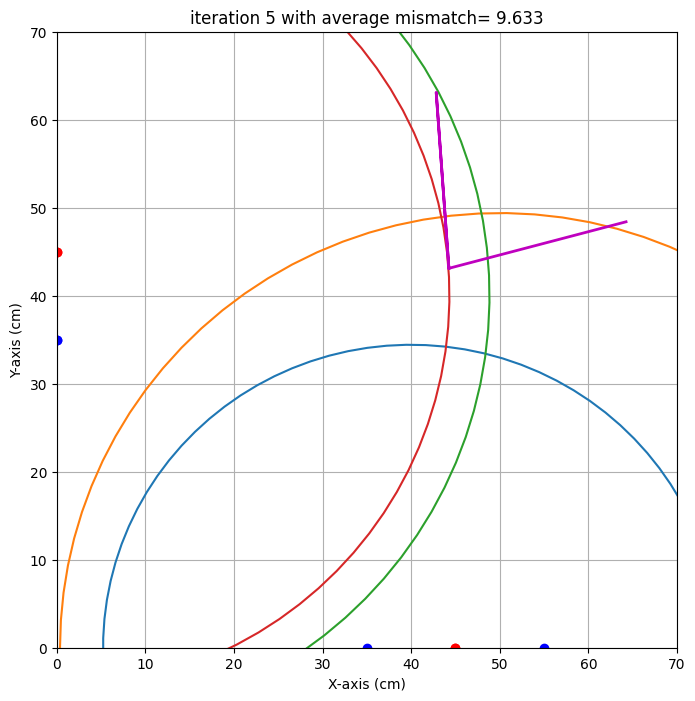

end iteration 5 with average mismatch= 9.633
end iteration 6 with average mismatch= 9.240


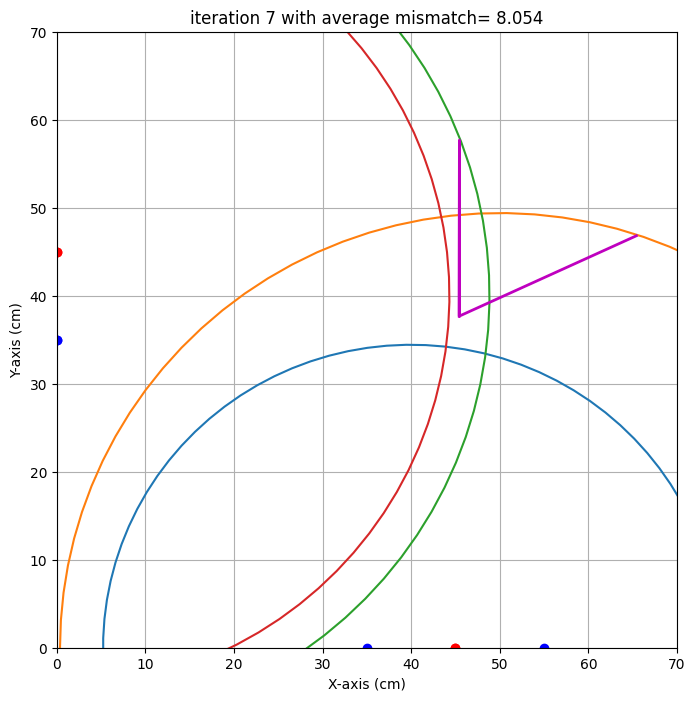

end iteration 7 with average mismatch= 8.054
end iteration 8 with average mismatch= 8.023


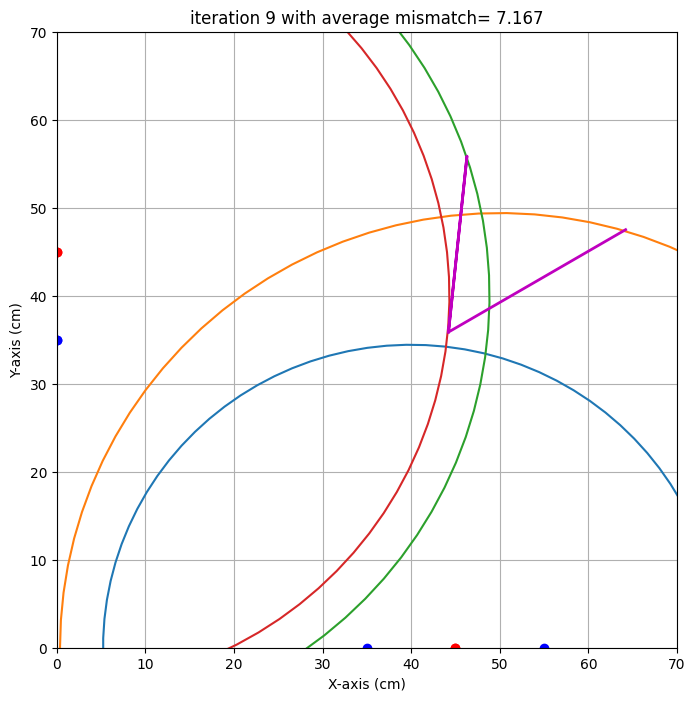

end iteration 9 with average mismatch= 7.167
end iteration 10 with average mismatch= 7.167
end iteration 11 with average mismatch= 6.923


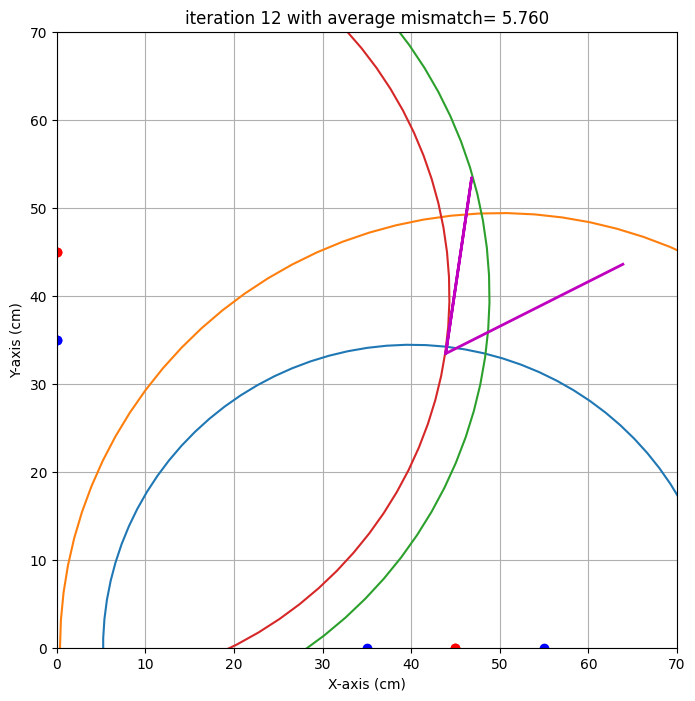

end iteration 12 with average mismatch= 5.760
end iteration 13 with average mismatch= 5.492
end iteration 14 with average mismatch= 5.305
end iteration 15 with average mismatch= 5.214
end iteration 16 with average mismatch= 5.053
end iteration 17 with average mismatch= 4.775
end iteration 18 with average mismatch= 4.447
end iteration 19 with average mismatch= 4.447
end iteration 20 with average mismatch= 4.447
end iteration 21 with average mismatch= 4.444
end iteration 22 with average mismatch= 4.370
end iteration 23 with average mismatch= 4.006
end iteration 24 with average mismatch= 3.732
end iteration 25 with average mismatch= 3.732
end iteration 26 with average mismatch= 3.732
end iteration 27 with average mismatch= 3.732
end iteration 28 with average mismatch= 3.732
end iteration 29 with average mismatch= 3.732
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 3.732
#################

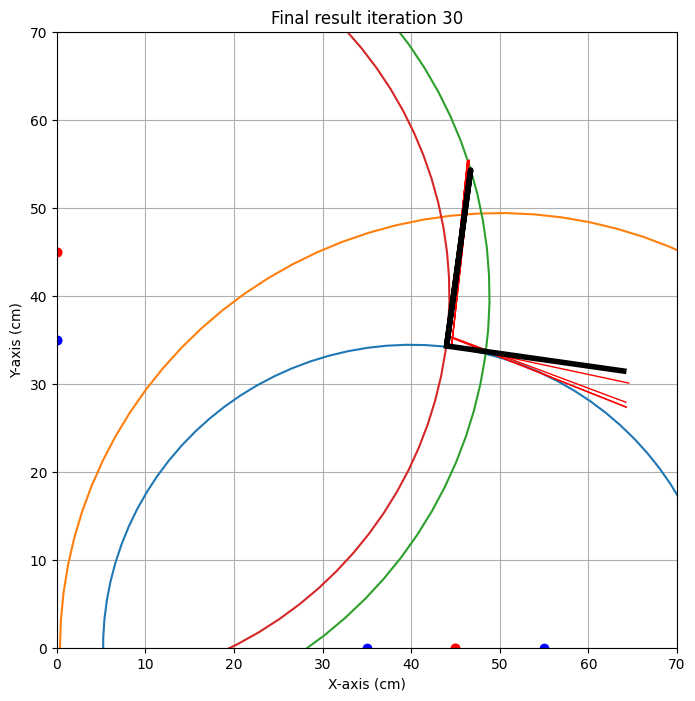

{'alpha': np.float64(-8.111221449725779), 'alpha_eps': np.float64(13.709686145919466), 'beta': np.float64(7.7473117025878295), 'beta_eps': np.float64(1.7608483412760325), 'x0': np.float64(43.9957874656728), 'x0_eps': np.float64(0.5765417659955077), 'y0': np.float64(34.29117448253102), 'y0_eps': np.float64(1.139380301226943)}
niels
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  60  68.8
1   0  40   0  50  94.0
2  35   0  40   0  98.0
3  20   0  25   0  97.0
4  50   0  40   0  98.6


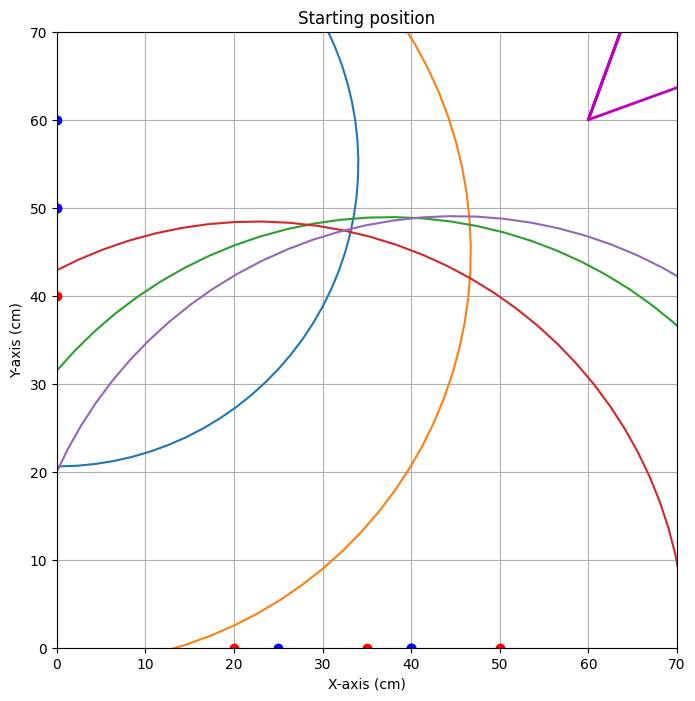


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.094


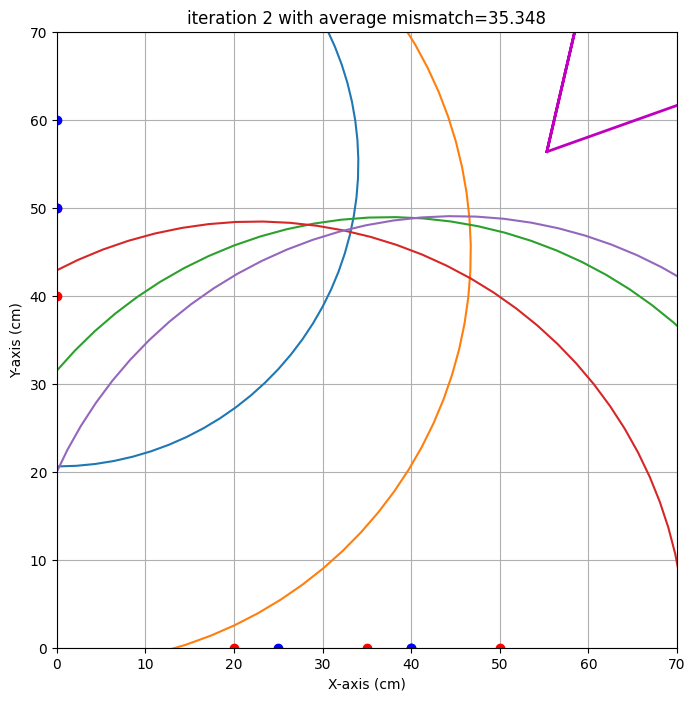

end iteration 2 with average mismatch=35.348


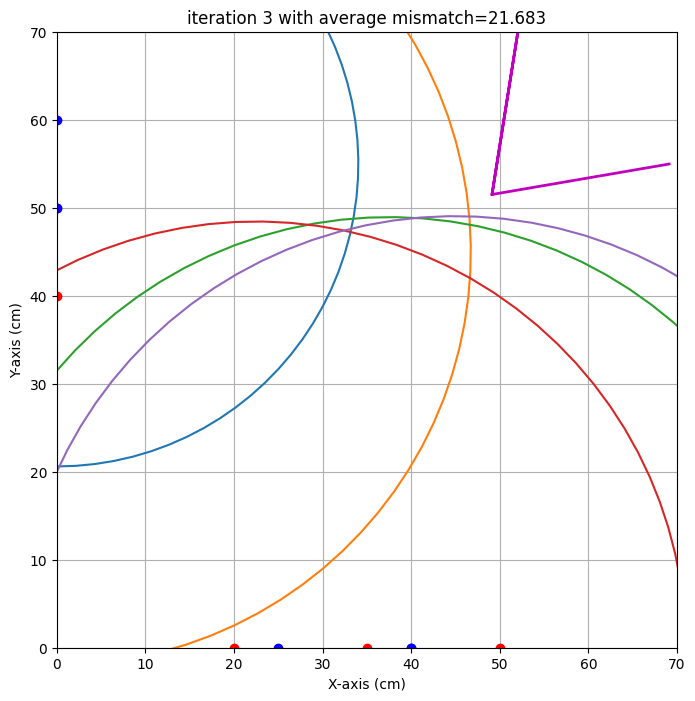

end iteration 3 with average mismatch=21.683


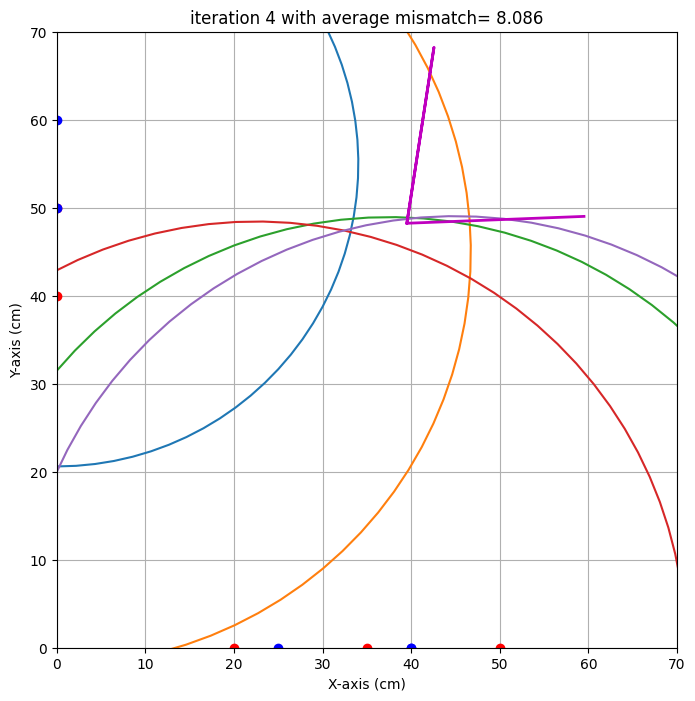

end iteration 4 with average mismatch= 8.086


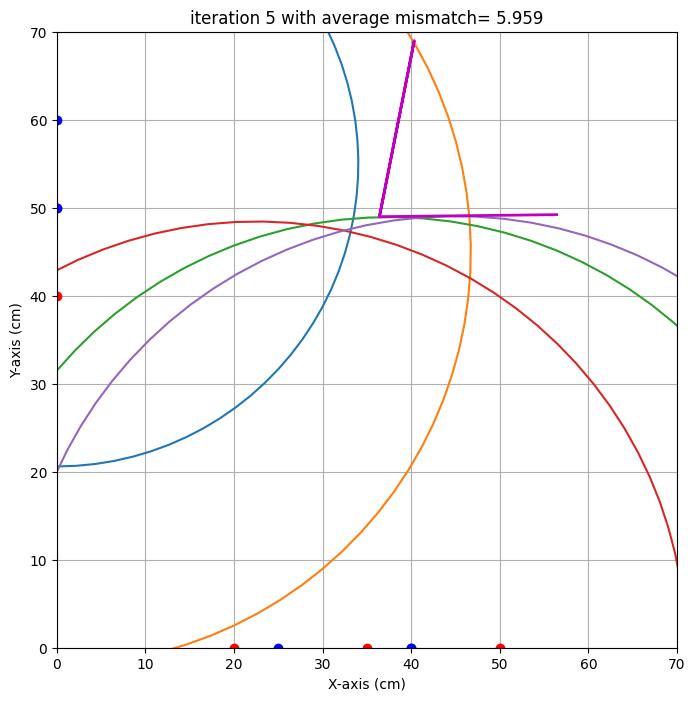

end iteration 5 with average mismatch= 5.959
end iteration 6 with average mismatch= 5.726
end iteration 7 with average mismatch= 5.635
end iteration 8 with average mismatch= 5.328
end iteration 9 with average mismatch= 5.327
end iteration 10 with average mismatch= 5.277
end iteration 11 with average mismatch= 5.276
end iteration 12 with average mismatch= 5.276
end iteration 13 with average mismatch= 5.276
end iteration 14 with average mismatch= 5.275
end iteration 15 with average mismatch= 5.274
end iteration 16 with average mismatch= 5.170
end iteration 17 with average mismatch= 5.168
end iteration 18 with average mismatch= 5.166
end iteration 19 with average mismatch= 5.166
end iteration 20 with average mismatch= 5.165
end iteration 21 with average mismatch= 5.165
end iteration 22 with average mismatch= 5.165
end iteration 23 with average mismatch= 5.165
end iteration 24 with average mismatch= 5.165
end iteration 25 with average mismatch= 5.165
end iteration 26 with average mismatch=

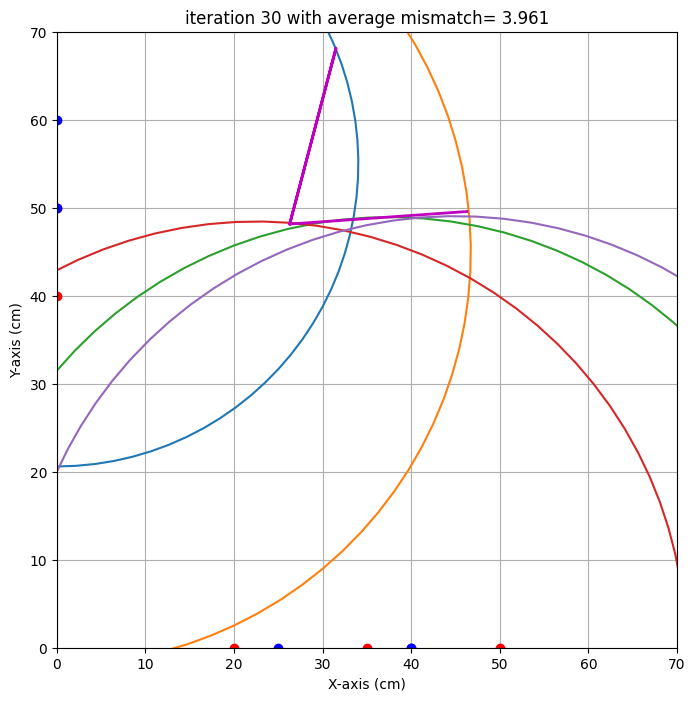

end iteration 30 with average mismatch= 3.961
###############################################################################
end of iteration  30
Best alpha=   4.07 with uncertainty=   0.55
Best beta =  14.66 with uncertainty=   0.35
Best x0   =  26.28 with uncertainty=   0.01
Best y0   =  48.15 with uncertainty=   0.24
###############################################################################


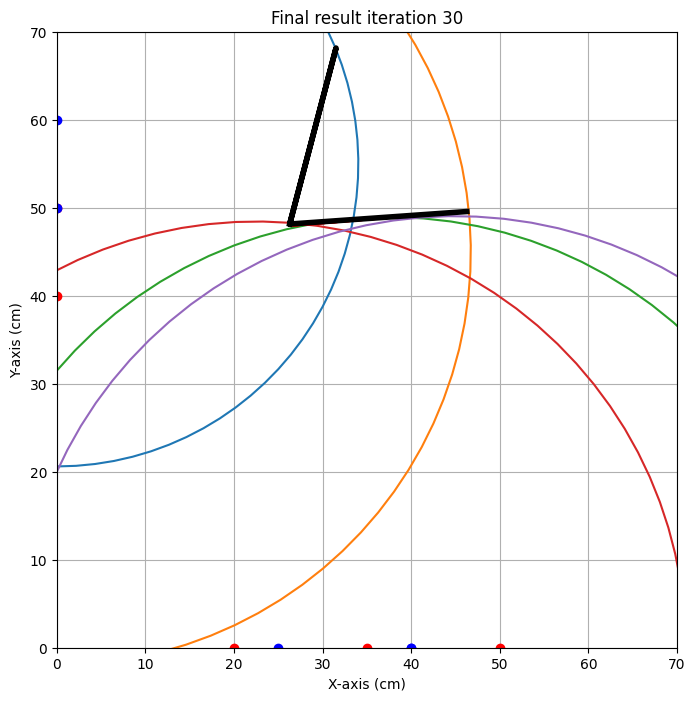

{'alpha': np.float64(4.067557432488017), 'alpha_eps': np.float64(0.5499263142696496), 'beta': np.float64(14.656804120523507), 'beta_eps': np.float64(0.35083481759814106), 'x0': np.float64(26.282364299336017), 'x0_eps': np.float64(0.006987174344352809), 'y0': np.float64(48.145128344418225), 'y0_eps': np.float64(0.24271757946886652)}
jelle
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  50   0  56   62
1   0  60   0  56   63
2  50   0  59   0  108
3  40   0  64   0  148


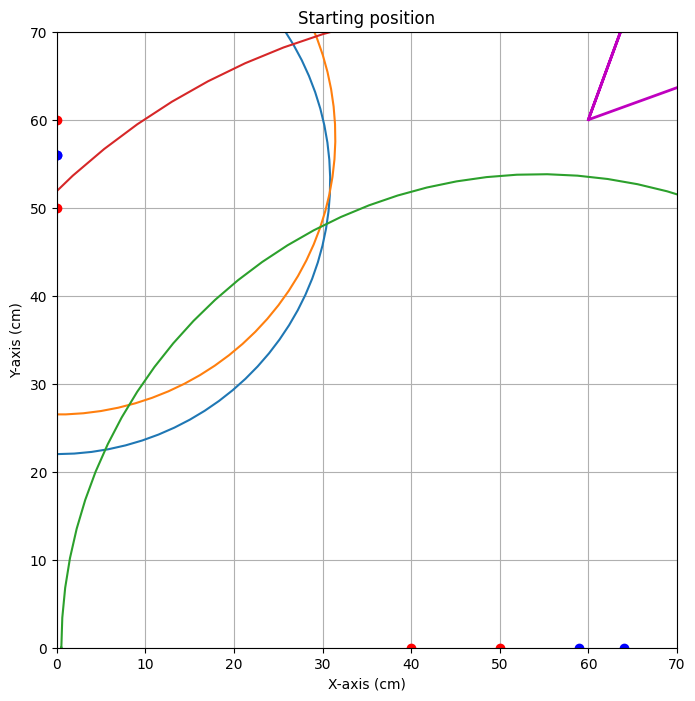


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.992


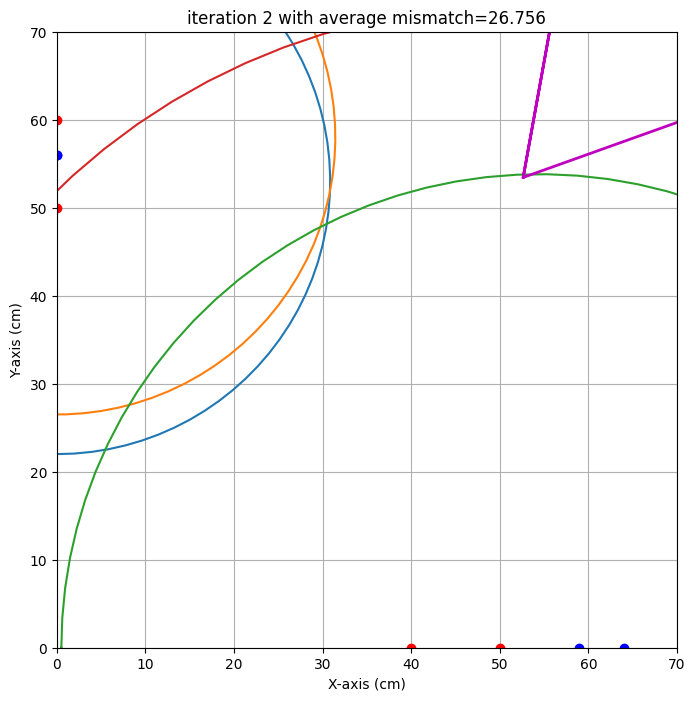

end iteration 2 with average mismatch=26.756


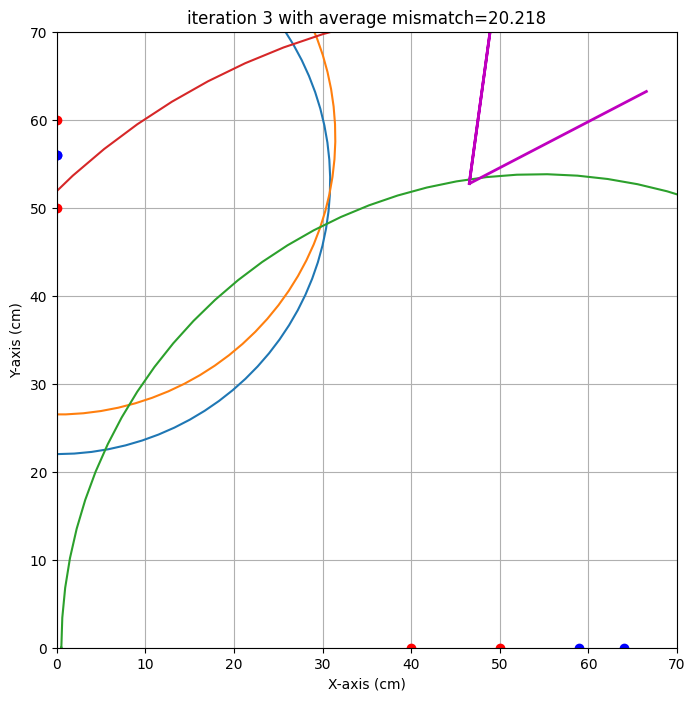

end iteration 3 with average mismatch=20.218


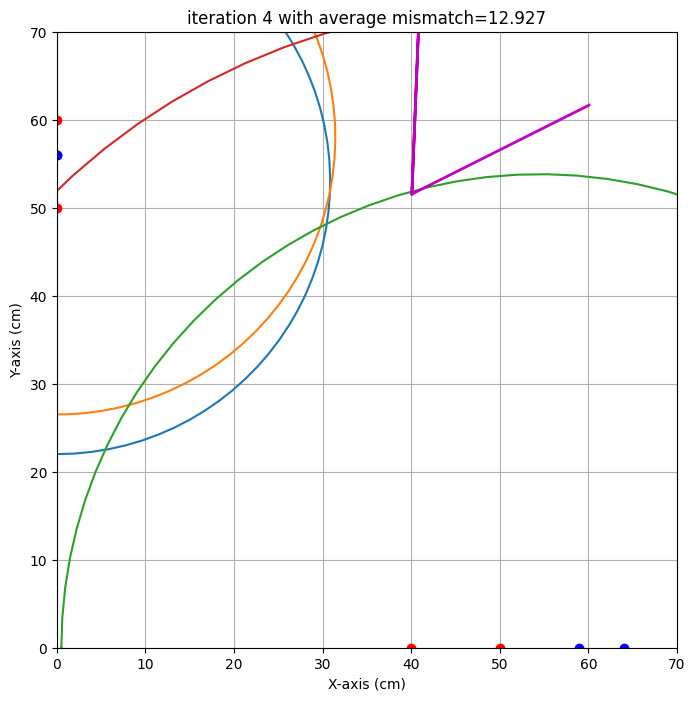

end iteration 4 with average mismatch=12.927


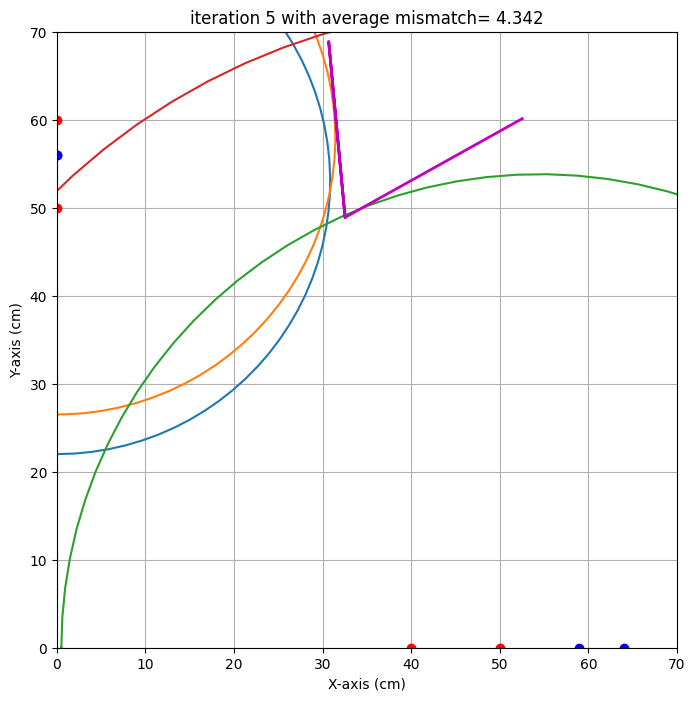

end iteration 5 with average mismatch= 4.342
end iteration 6 with average mismatch= 4.128
end iteration 7 with average mismatch= 3.855


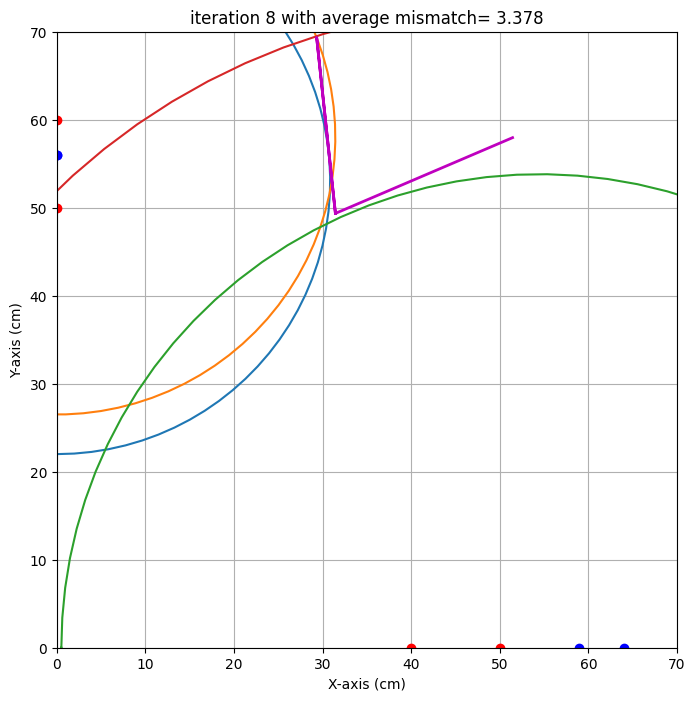

end iteration 8 with average mismatch= 3.378
end iteration 9 with average mismatch= 3.316
end iteration 10 with average mismatch= 3.316
end iteration 11 with average mismatch= 3.316
end iteration 12 with average mismatch= 3.316
end iteration 13 with average mismatch= 3.316
end iteration 14 with average mismatch= 3.316
end iteration 15 with average mismatch= 3.316
end iteration 16 with average mismatch= 3.316
end iteration 17 with average mismatch= 3.316
end iteration 18 with average mismatch= 3.316
end iteration 19 with average mismatch= 3.290
end iteration 20 with average mismatch= 3.290
end iteration 21 with average mismatch= 3.290
end iteration 22 with average mismatch= 3.151
end iteration 23 with average mismatch= 3.100
end iteration 24 with average mismatch= 3.100
end iteration 25 with average mismatch= 3.058
end iteration 26 with average mismatch= 3.058
end iteration 27 with average mismatch= 3.058
end iteration 28 with average mismatch= 3.058
end iteration 29 with average mismat

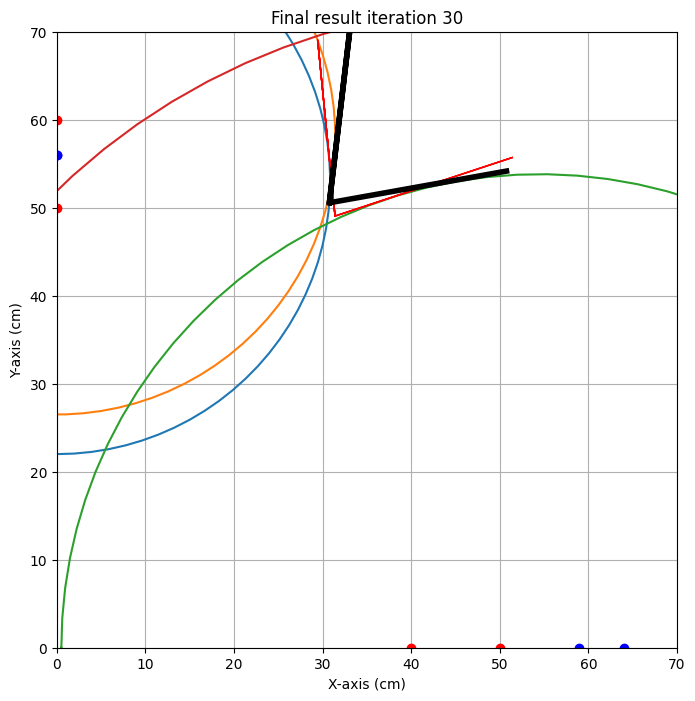

{'alpha': np.float64(10.20604511083307), 'alpha_eps': np.float64(8.178791062537531), 'beta': np.float64(6.718719930295717), 'beta_eps': np.float64(12.32270488994747), 'x0': np.float64(30.76131183874129), 'x0_eps': np.float64(0.6401973770439362), 'y0': np.float64(50.56200476238962), 'y0_eps': np.float64(1.5093584130461224)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

kris 
x0 target is : 49.0. Gevonden waarde: 44.0 cm met een standaardafwijking van 0.6 cm 
y0 target is : 49.0. Gevonden waarde: 34.3 cm met een standaardafwijking van 1.1 cm 
alpha target is : 30.0. Gevonden waarde: -8.1 graden met een standaardafwijking van 13.7 graad 
beta target is : 180.0. Gevonden waarde: 7.7 graden met een standaardafwijking van 1.8 graad 

niels 
x0 target is : 49.0. Gevonden waarde: 26.3 cm met een standaardafwijking van 0.0 cm 
y0 target is : 49.0. Gevonden waarde: 48.1 cm met een standaardafwijking van 0.2 cm 
alpha target is : 30.0. Gevonden waarde: 4.1 graden met een standaardafwijking van 0.5 graad 
beta target is : 180.0. Gevonden waarde: 14.7 graden met een standaardafwijking van 0.4 graad 

jelle 
x0 target is : 49.0. Gevonden waarde: 30.8 cm met een standaardafwijking van 0.6 cm 
y0 target is : 49.0. Gevonden waarde: 50.6 cm met een standaardafwijking van 1.5 cm 
alpha target is : 30.0. Gevonden waarde: 10.2 graden met een standaardafwijking van 8.2 g

## Opdracht 8: Iteratie1+.14:37
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie_2.jpeg)
Figuur: ![Alt](iteratie_3.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  84.5
1   0  45   0  55  68.6
2   0  50   0  60  69.3
3  38   0  48   0  84.2


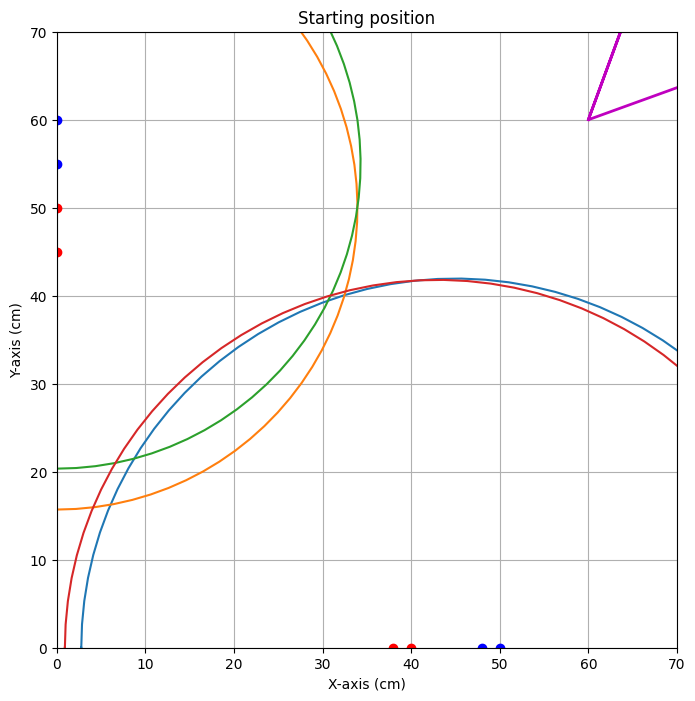


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.318


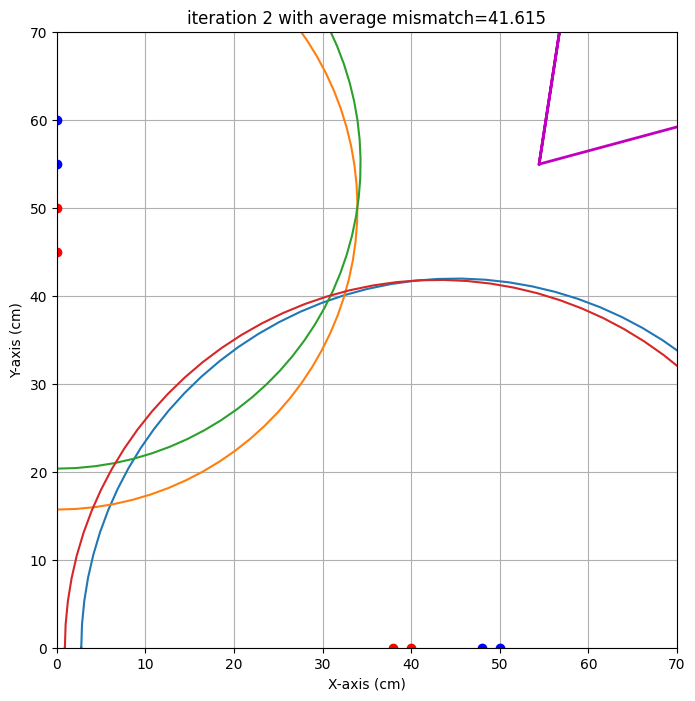

end iteration 2 with average mismatch=41.615


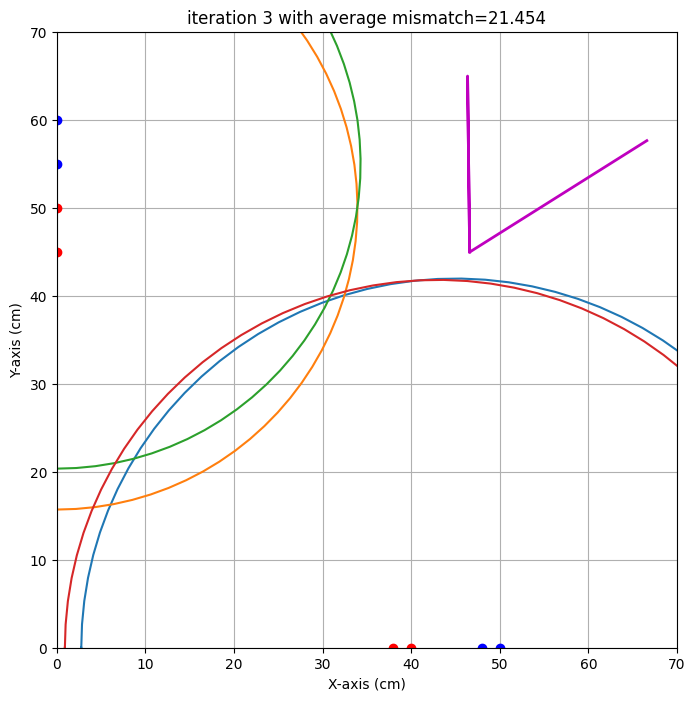

end iteration 3 with average mismatch=21.454


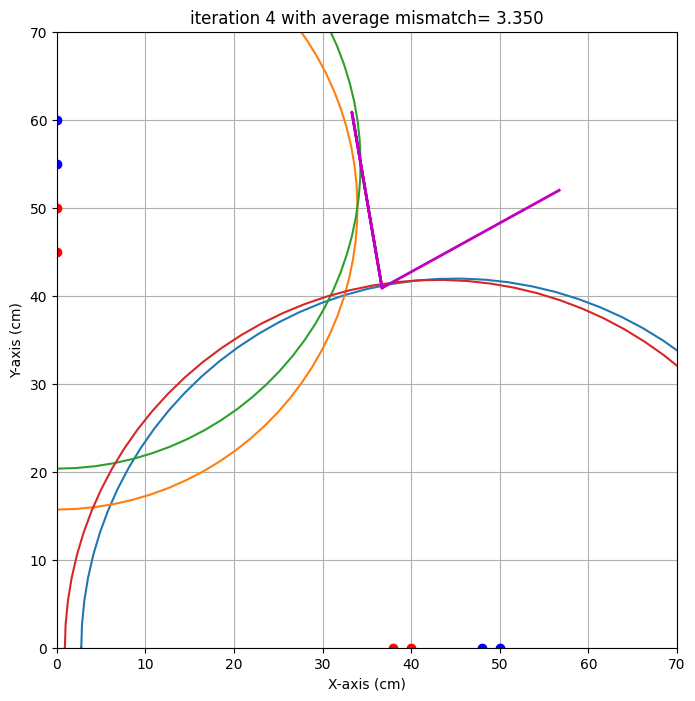

end iteration 4 with average mismatch= 3.350


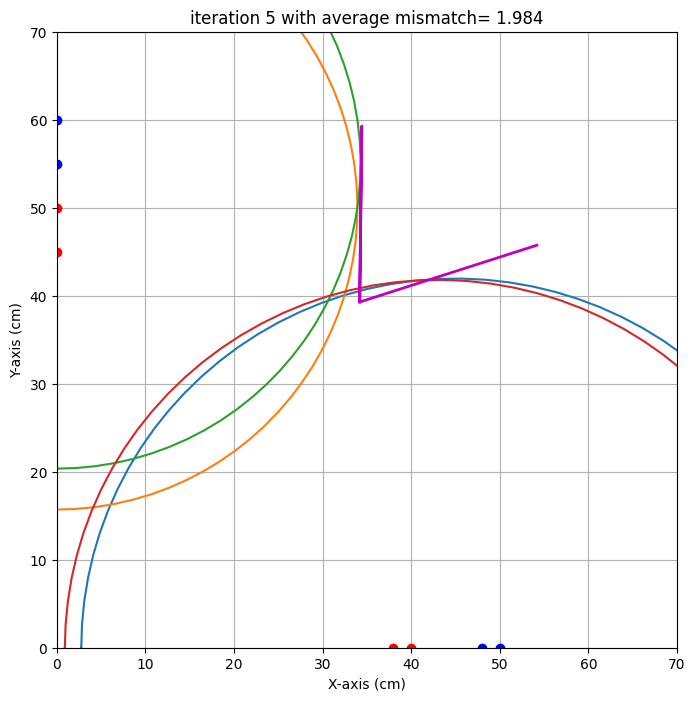

end iteration 5 with average mismatch= 1.984


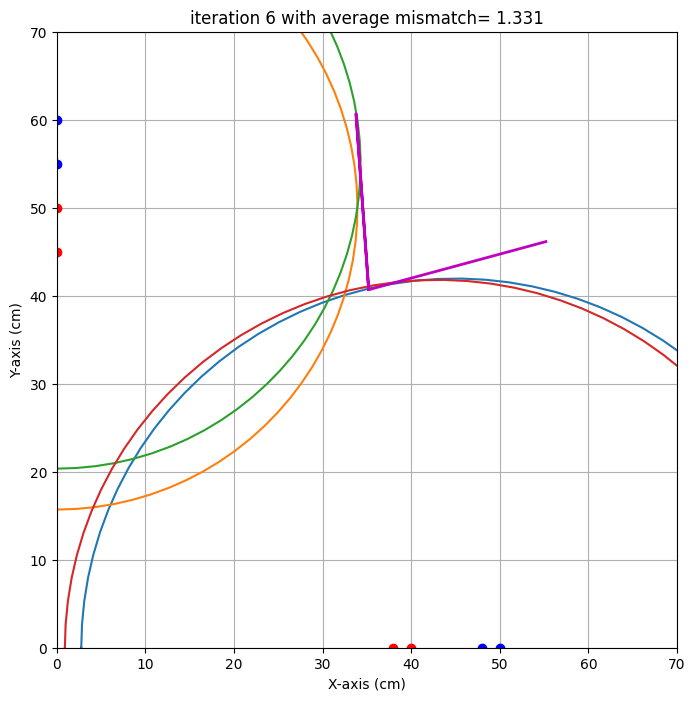

end iteration 6 with average mismatch= 1.331


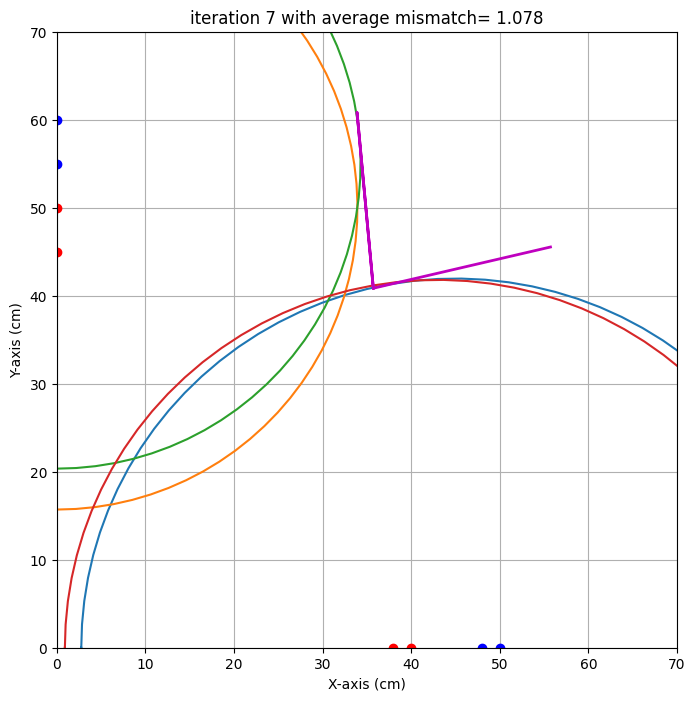

end iteration 7 with average mismatch= 1.078


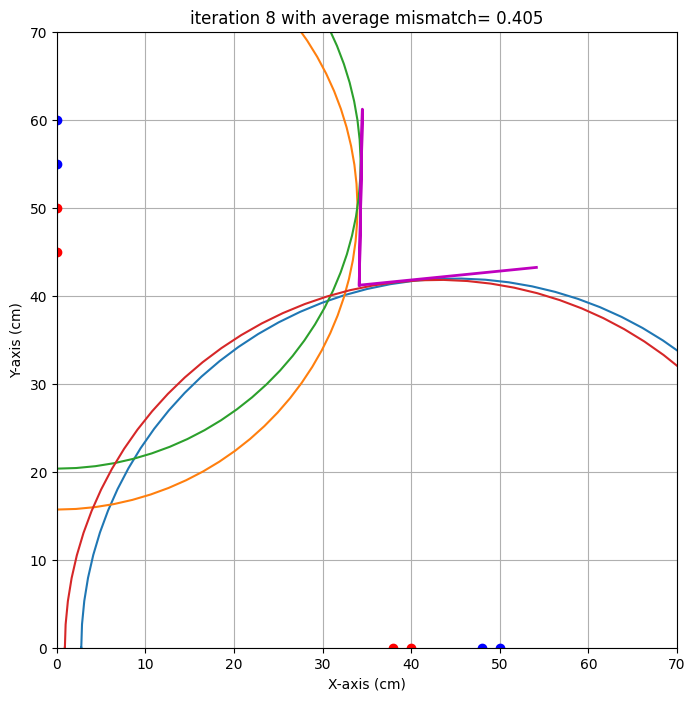

end iteration 8 with average mismatch= 0.405


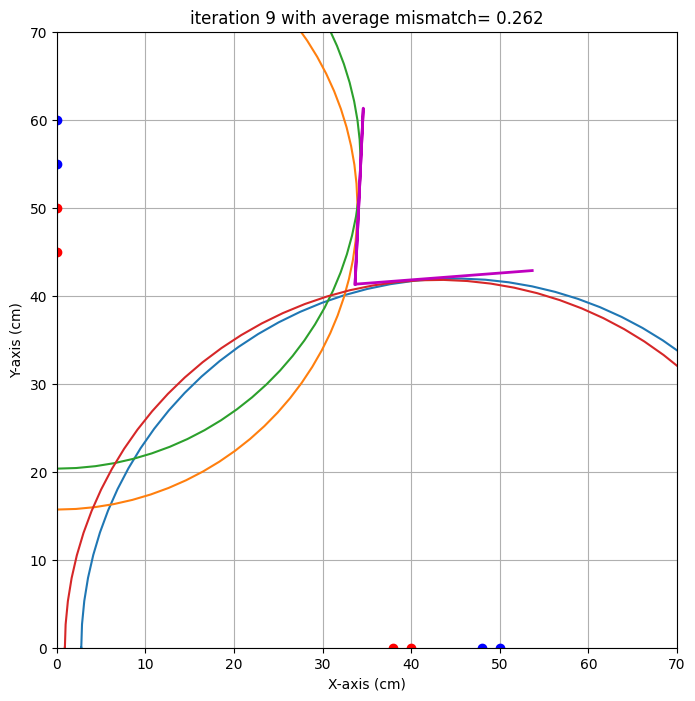

end iteration 9 with average mismatch= 0.262


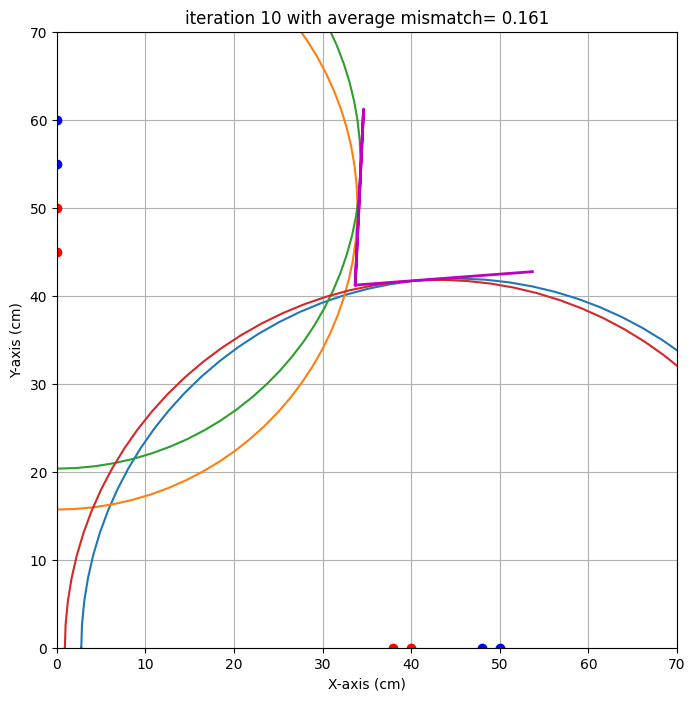

end iteration 10 with average mismatch= 0.161
end iteration 11 with average mismatch= 0.157
end iteration 12 with average mismatch= 0.157


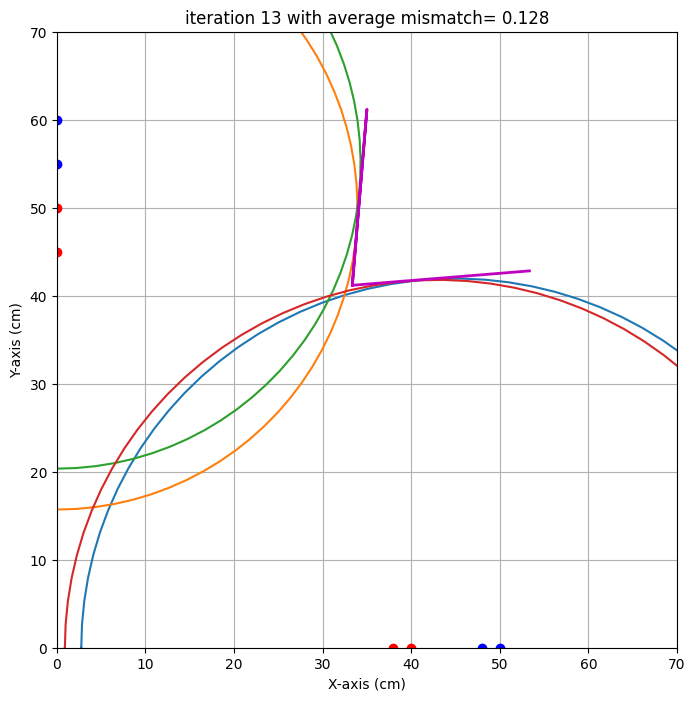

end iteration 13 with average mismatch= 0.128


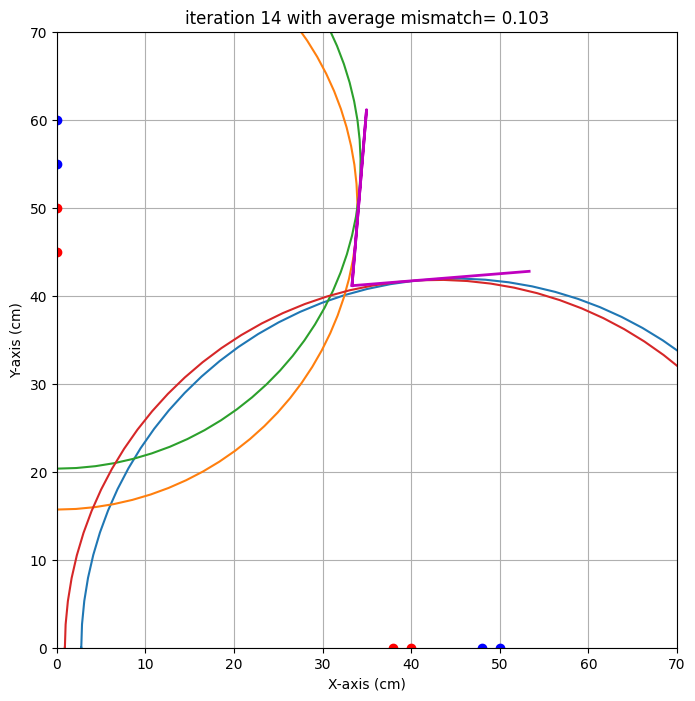

end iteration 14 with average mismatch= 0.103
end iteration 15 with average mismatch= 0.103
end iteration 16 with average mismatch= 0.103
end iteration 17 with average mismatch= 0.103
end iteration 18 with average mismatch= 0.103
end iteration 19 with average mismatch= 0.095
end iteration 20 with average mismatch= 0.092
end iteration 21 with average mismatch= 0.092
end iteration 22 with average mismatch= 0.092
end iteration 23 with average mismatch= 0.092
end iteration 24 with average mismatch= 0.092
end iteration 25 with average mismatch= 0.092
end iteration 26 with average mismatch= 0.092
end iteration 27 with average mismatch= 0.092
end iteration 28 with average mismatch= 0.092
end iteration 29 with average mismatch= 0.092
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.092
###############################################################################
end of iteration  30
Best alp

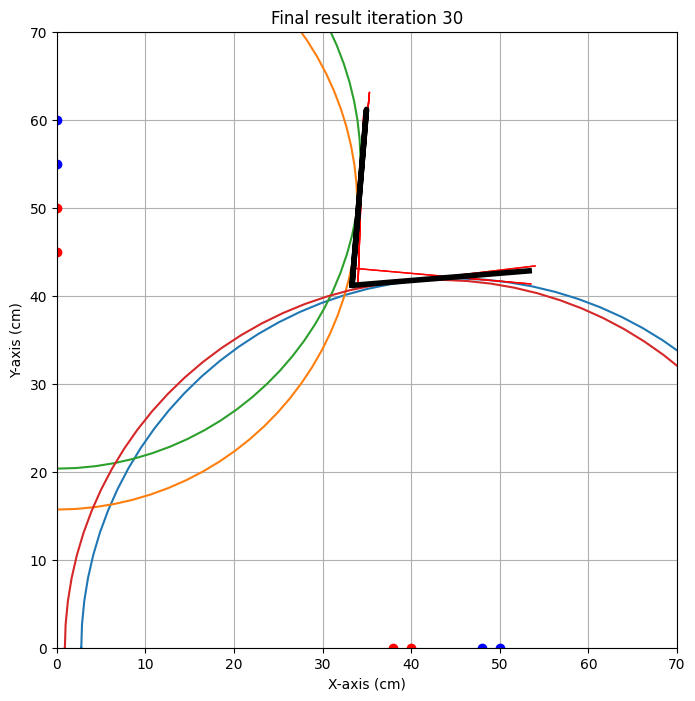

{'alpha': np.float64(4.715196035874476), 'alpha_eps': np.float64(9.803686980195696), 'beta': np.float64(4.672213696803529), 'beta_eps': np.float64(2.7787285184855604), 'x0': np.float64(33.32086599254012), 'x0_eps': np.float64(0.6676983728528469), 'y0': np.float64(41.17722167517215), 'y0_eps': np.float64(1.9428394040085948)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  92.3
1   0  50   0  60  68.0
2   0  55   0  65  65.7
3  45   0  55   0  91.7


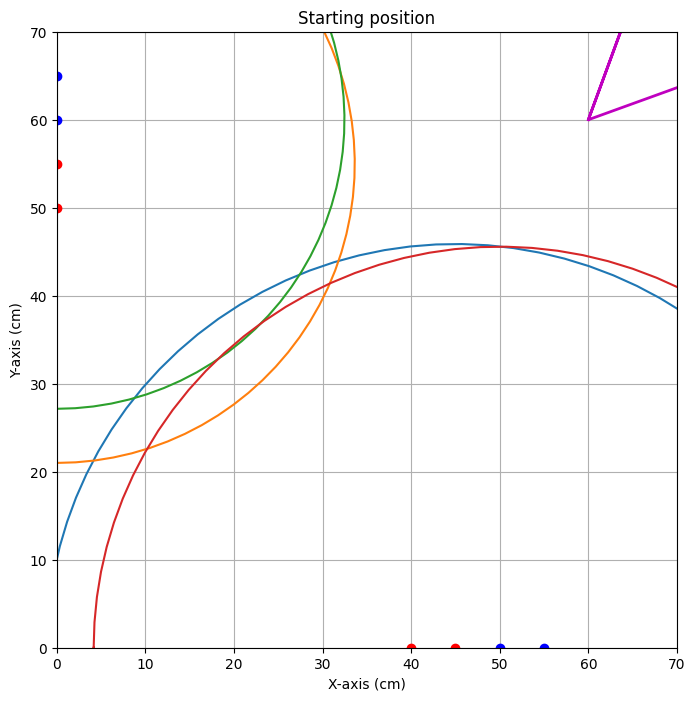


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.004


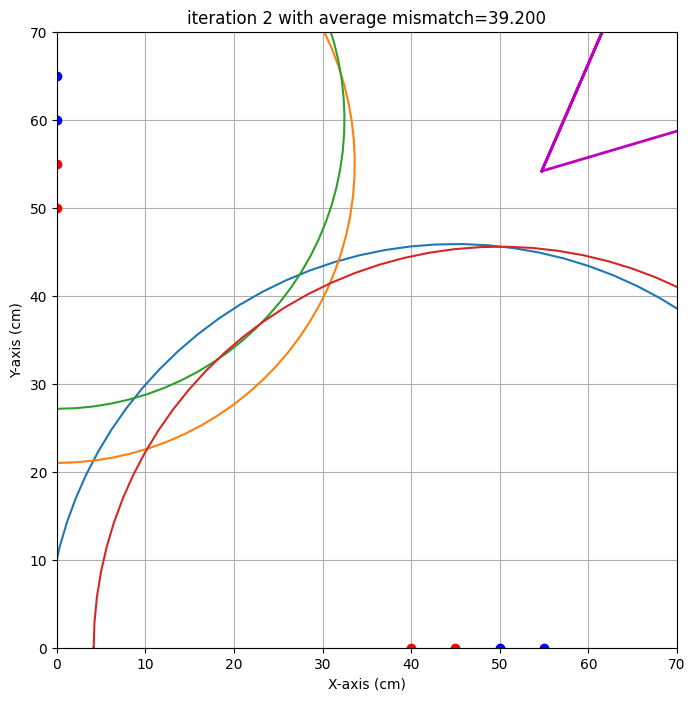

end iteration 2 with average mismatch=39.200


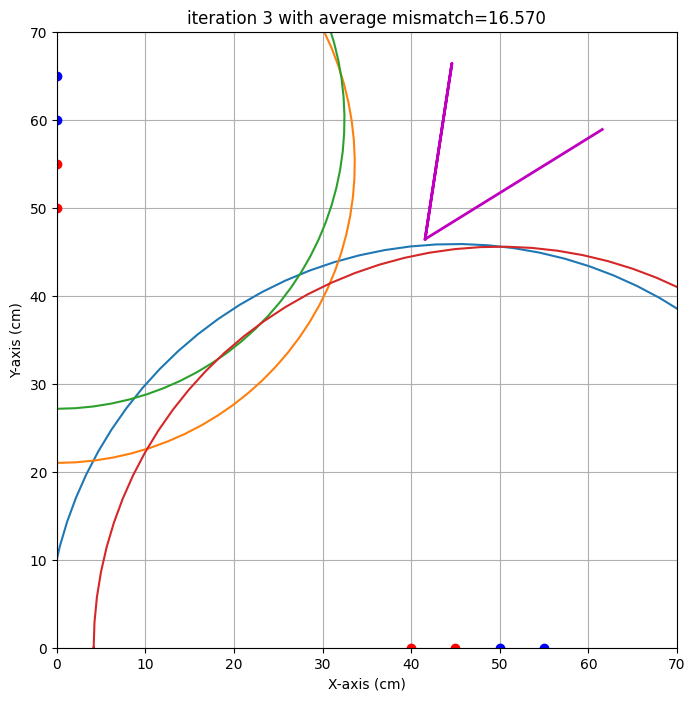

end iteration 3 with average mismatch=16.570


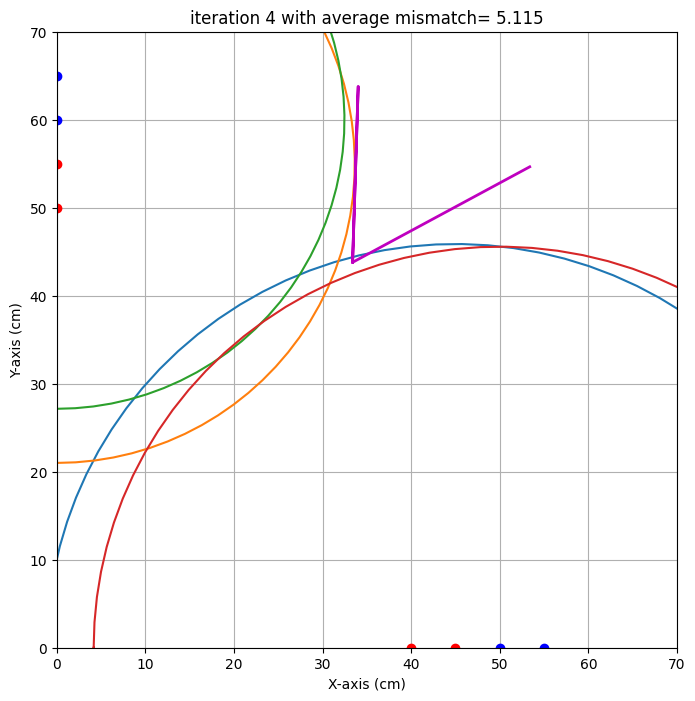

end iteration 4 with average mismatch= 5.115


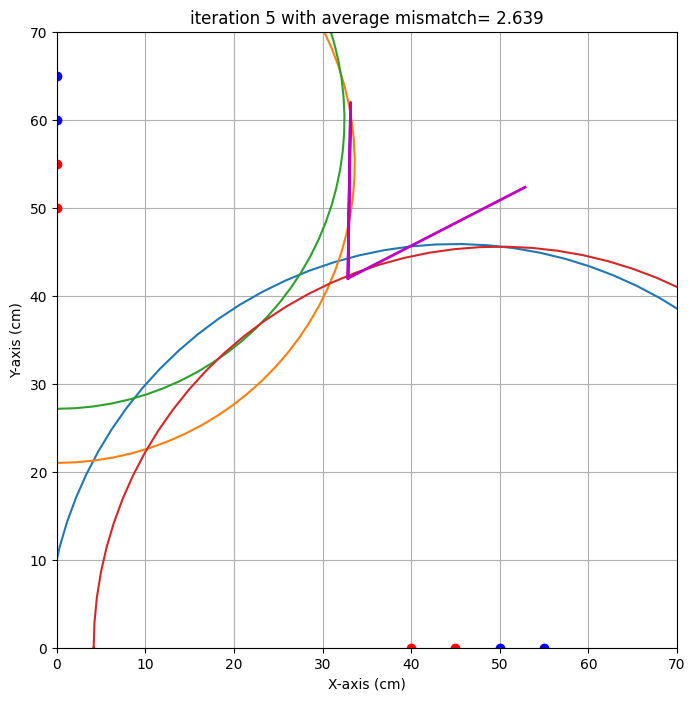

end iteration 5 with average mismatch= 2.639


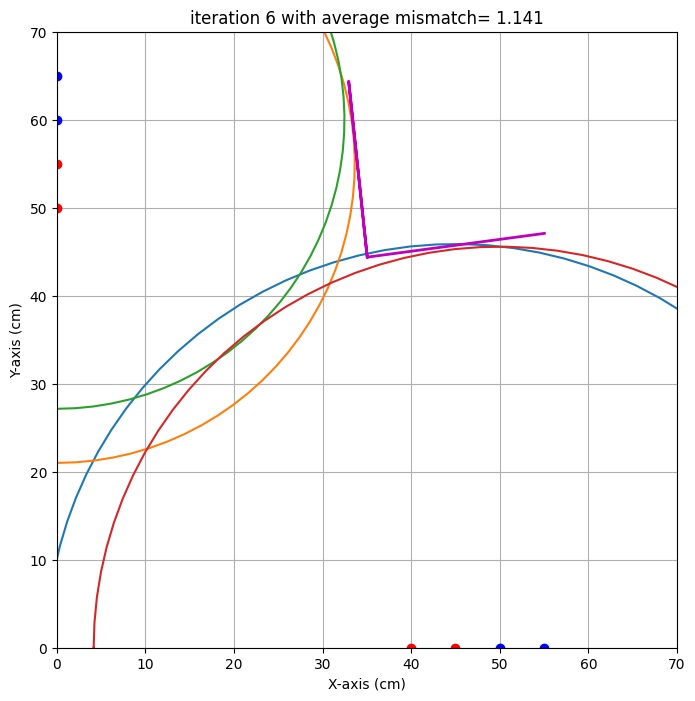

end iteration 6 with average mismatch= 1.141
end iteration 7 with average mismatch= 1.068


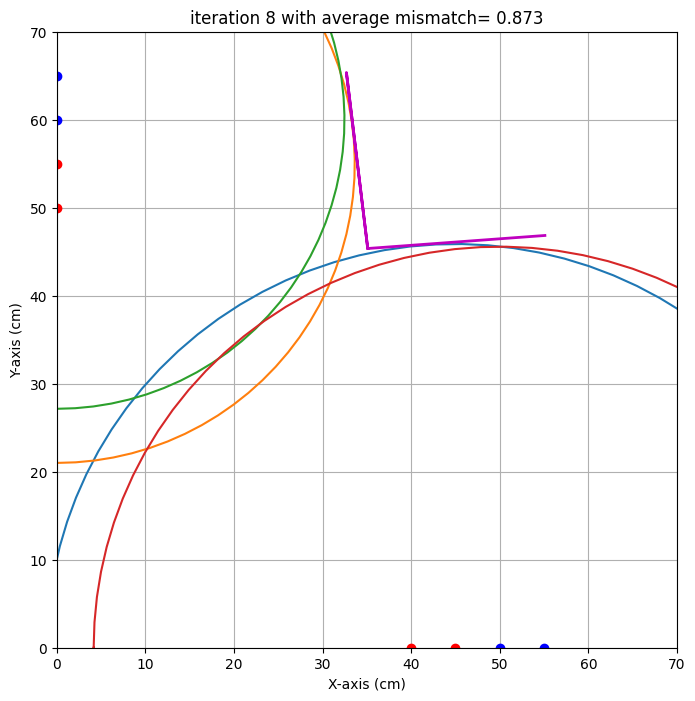

end iteration 8 with average mismatch= 0.873


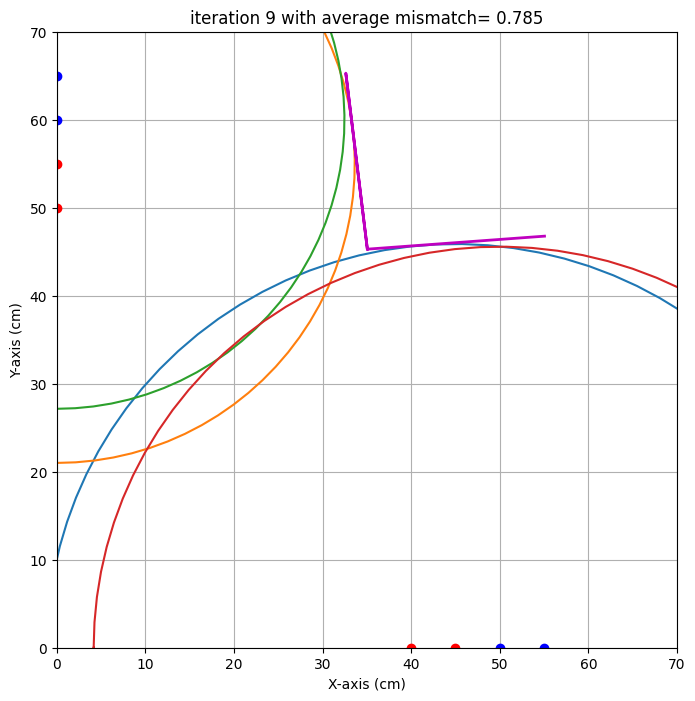

end iteration 9 with average mismatch= 0.785


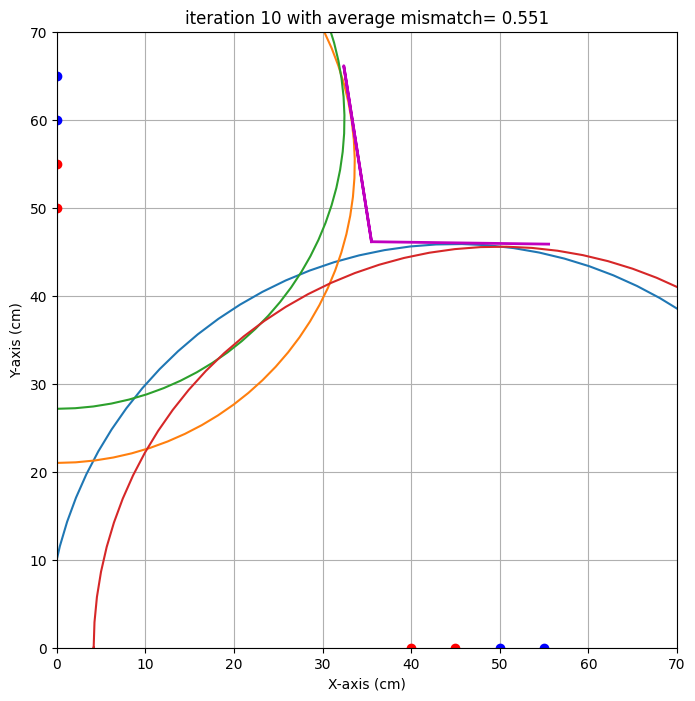

end iteration 10 with average mismatch= 0.551


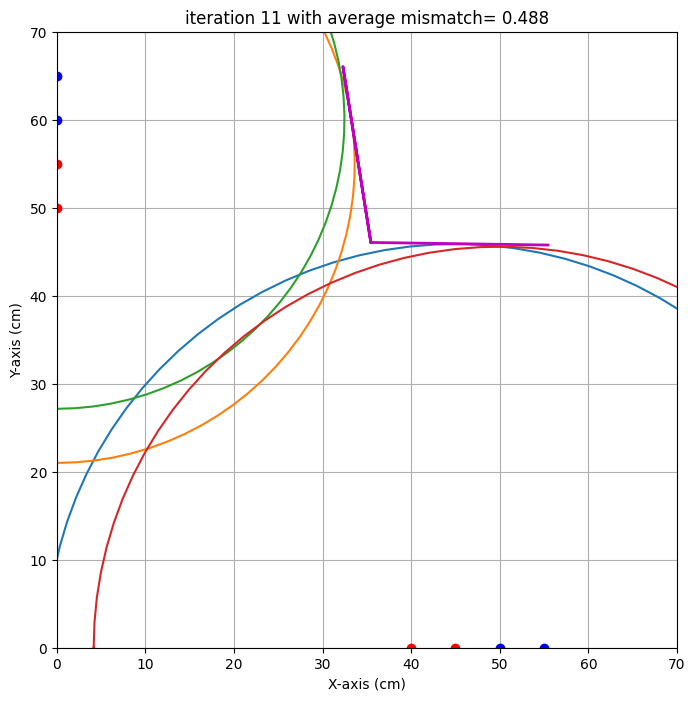

end iteration 11 with average mismatch= 0.488
end iteration 12 with average mismatch= 0.444
end iteration 13 with average mismatch= 0.442
end iteration 14 with average mismatch= 0.441
end iteration 15 with average mismatch= 0.441


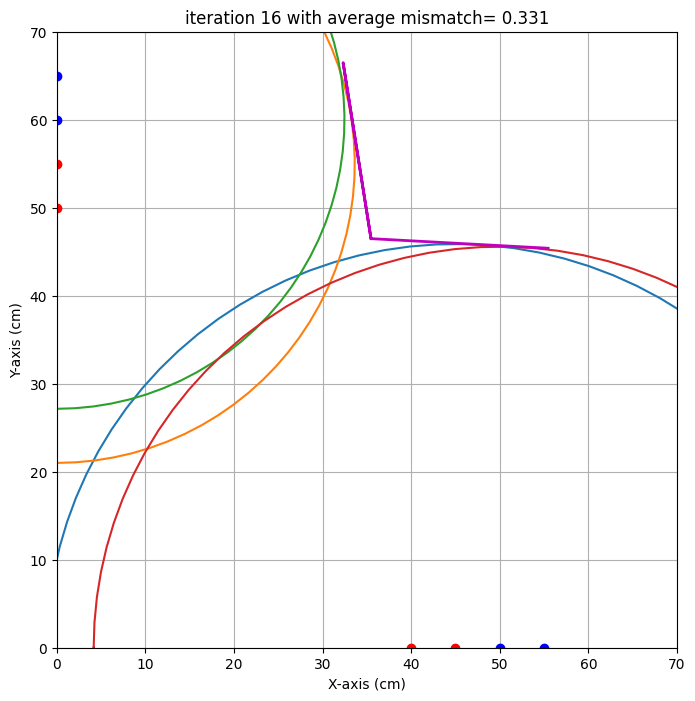

end iteration 16 with average mismatch= 0.331
end iteration 17 with average mismatch= 0.329
end iteration 18 with average mismatch= 0.324
end iteration 19 with average mismatch= 0.315
end iteration 20 with average mismatch= 0.315
end iteration 21 with average mismatch= 0.315
end iteration 22 with average mismatch= 0.315
end iteration 23 with average mismatch= 0.315
end iteration 24 with average mismatch= 0.315
end iteration 25 with average mismatch= 0.315
end iteration 26 with average mismatch= 0.315
end iteration 27 with average mismatch= 0.315
end iteration 28 with average mismatch= 0.315
end iteration 29 with average mismatch= 0.302
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.283
###############################################################################
end of iteration  30
Best alpha=  -4.30 with uncertainty=   4.18
Best b

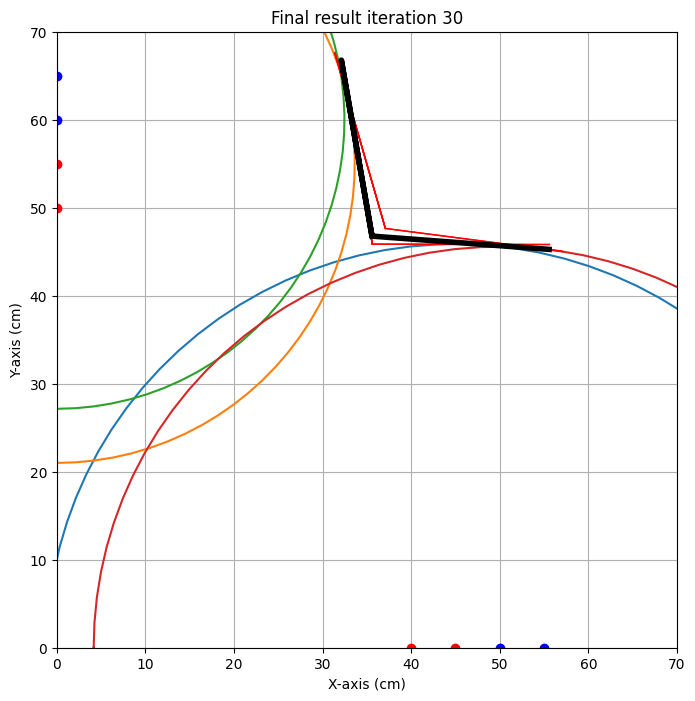

{'alpha': np.float64(-4.303120414442108), 'alpha_eps': np.float64(4.178061342840594), 'beta': np.float64(-9.823218745443588), 'beta_eps': np.float64(6.137972319109137), 'x0': np.float64(35.57525444866779), 'x0_eps': np.float64(1.511018728256417), 'y0': np.float64(46.772551265240445), 'y0_eps': np.float64(0.9097476955193002)}
locatie 1 
x0 target is : 35.0. Gevonden waarde: 33.3 cm met een standaardafwijking van 0.7 cm 
y0 target is : 40.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 1.9 cm 
alpha target is : 20.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 9.8 graad 
beta target is : 10.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 2.8 graad 

locatie 2 
x0 target is : 36.0. Gevonden waarde: 35.6 cm met een standaardafwijking van 1.5 cm 
y0 target is : 46.0. Gevonden waarde: 46.8 cm met een standaardafwijking van 0.9 cm 
alpha target is : 9.0. Gevonden waarde: -4.3 graden met een standaardafwijking van 4.2 graad 
beta target is : 3.0. Gevonde

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35,
                    'y0':40,
                    'alpha' : 20,
                    'beta' : 10,},
           'locatie 2':{'x0': 36,
                    'y0':46,
                    'alpha' : 9,
                    'beta' : 3}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,84.5],
    [0,45, 0,55,68.6],
    [0,50, 0, 60, 69.3],
    [38,0, 48, 0, 84.2]

    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 50, 0, 92.3],
    [0,50, 0,60, 68],
    [0,55, 0,65, 65.7],
    [45, 0, 55, 0, 91.7]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  89.7
1   0  48   0  58  78.4
2   0  53   0  63  77.8
3  48   0  58   0  88.2


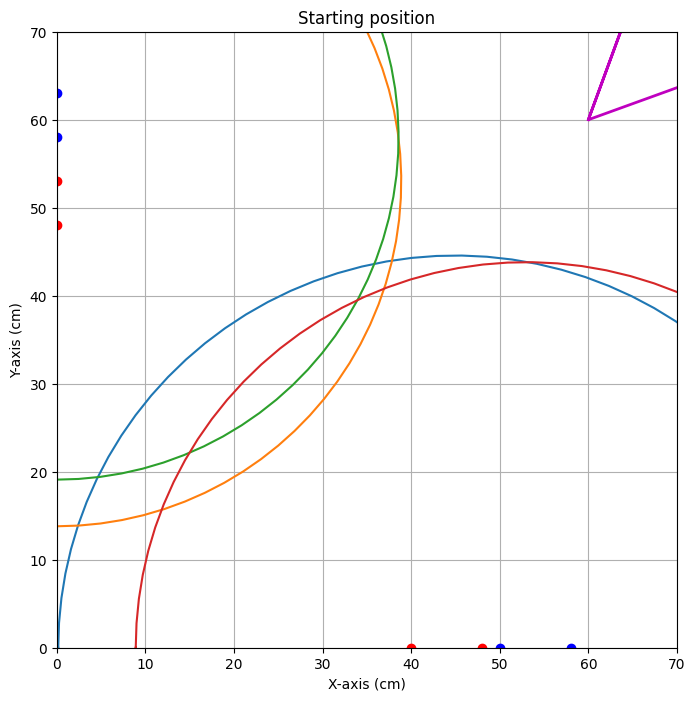


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.958


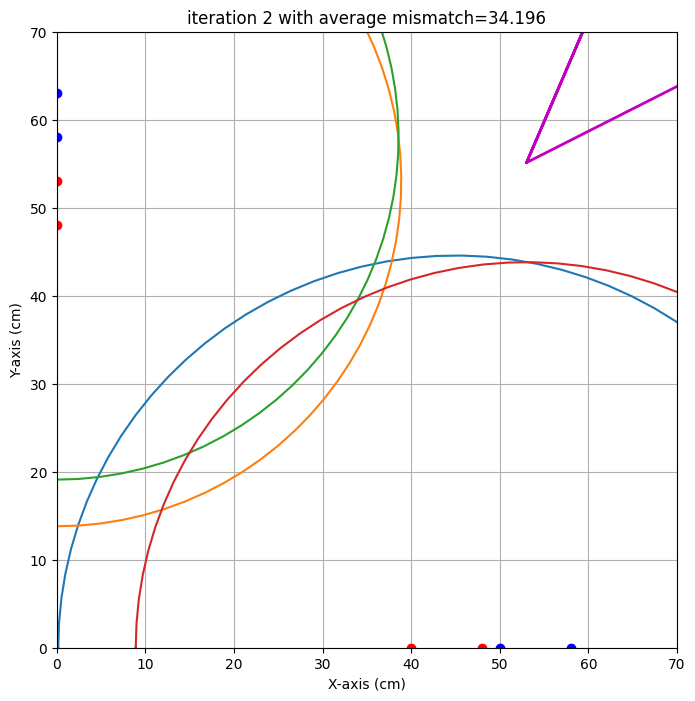

end iteration 2 with average mismatch=34.196


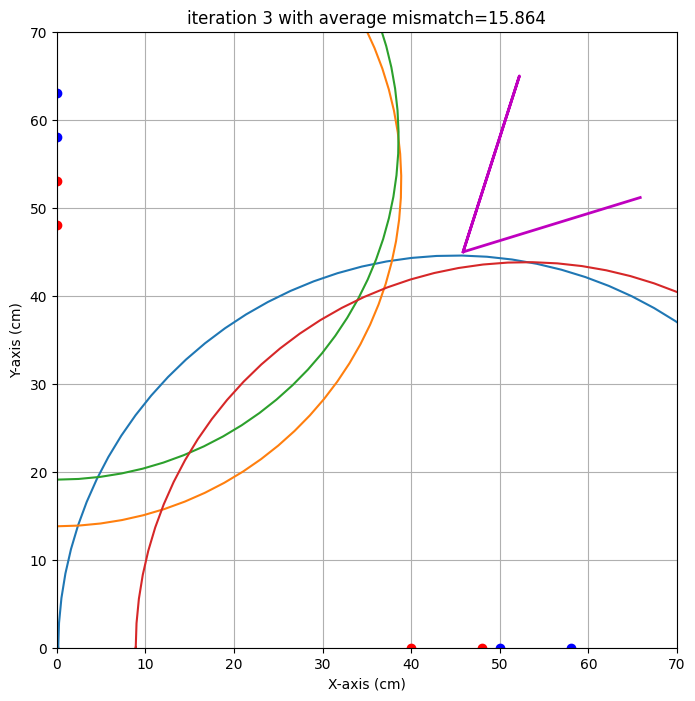

end iteration 3 with average mismatch=15.864


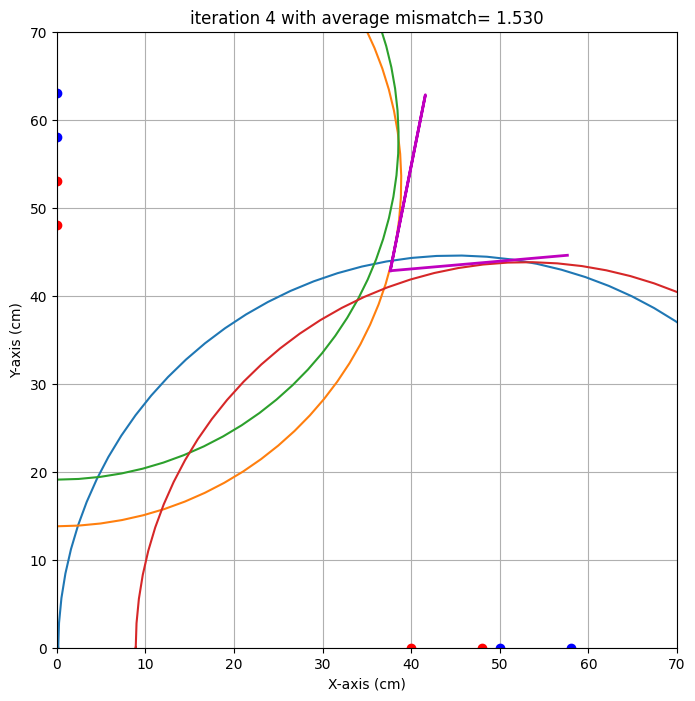

end iteration 4 with average mismatch= 1.530
end iteration 5 with average mismatch= 1.530


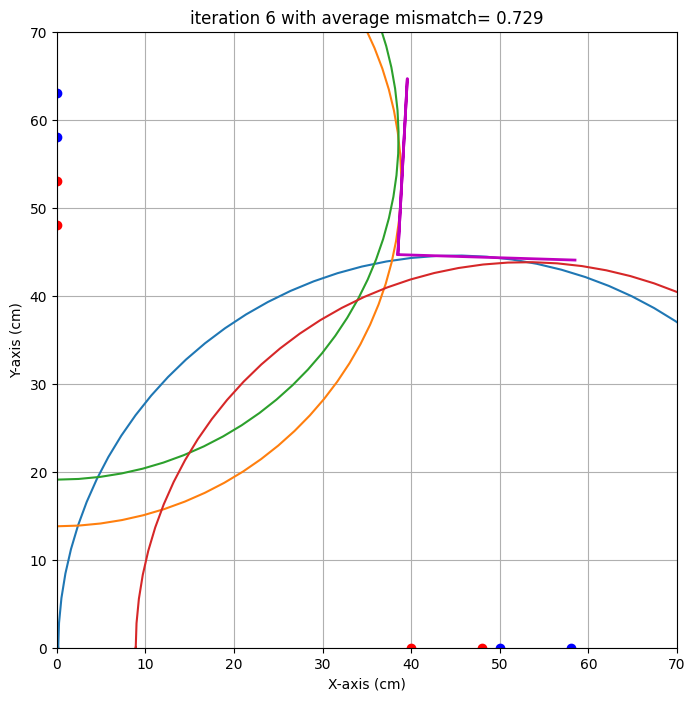

end iteration 6 with average mismatch= 0.729


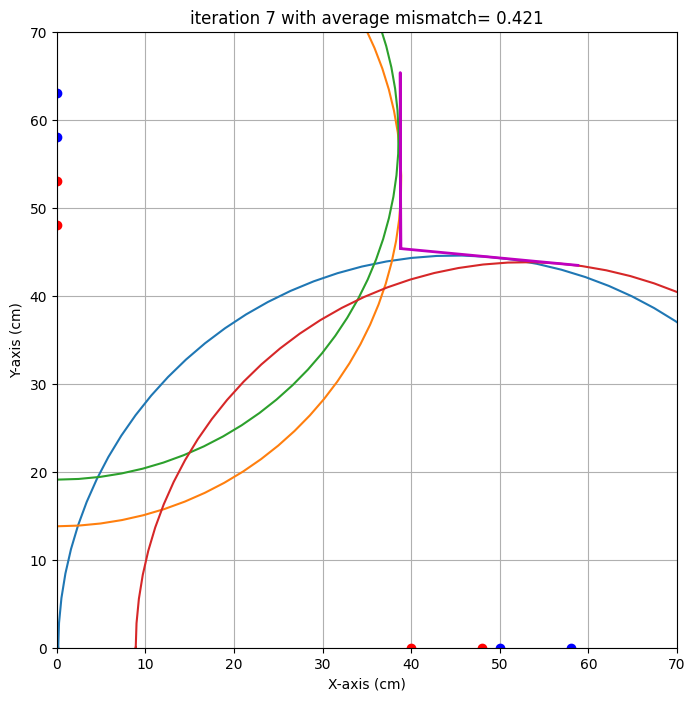

end iteration 7 with average mismatch= 0.421


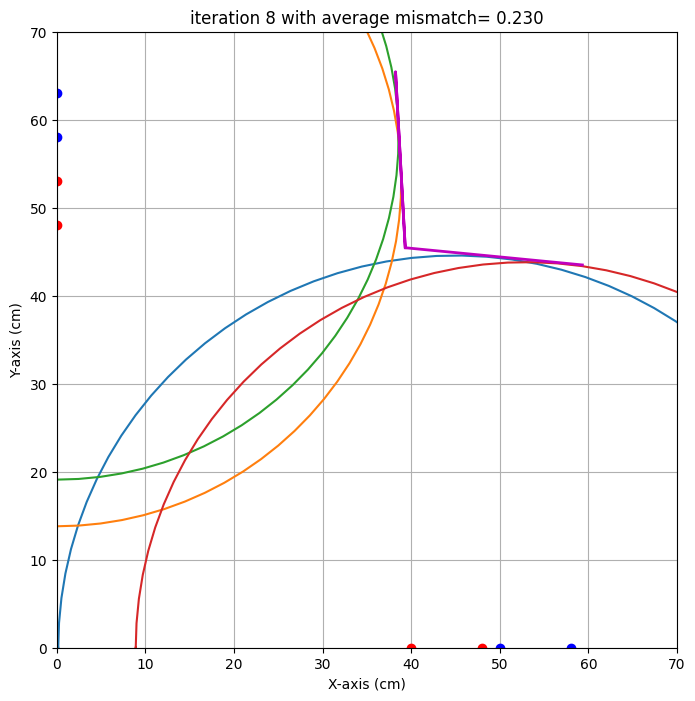

end iteration 8 with average mismatch= 0.230
end iteration 9 with average mismatch= 0.215
end iteration 10 with average mismatch= 0.208
end iteration 11 with average mismatch= 0.207
end iteration 12 with average mismatch= 0.207
end iteration 13 with average mismatch= 0.207
end iteration 14 with average mismatch= 0.201
end iteration 15 with average mismatch= 0.192
end iteration 16 with average mismatch= 0.190
end iteration 17 with average mismatch= 0.190
end iteration 18 with average mismatch= 0.190
end iteration 19 with average mismatch= 0.190
end iteration 20 with average mismatch= 0.190


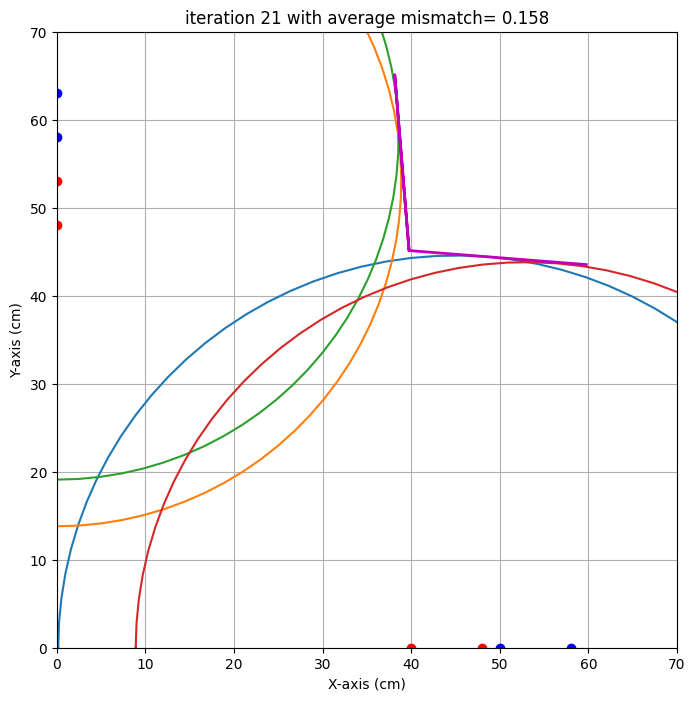

end iteration 21 with average mismatch= 0.158
end iteration 22 with average mismatch= 0.154
end iteration 23 with average mismatch= 0.153
end iteration 24 with average mismatch= 0.152
end iteration 25 with average mismatch= 0.152
end iteration 26 with average mismatch= 0.152
end iteration 27 with average mismatch= 0.152


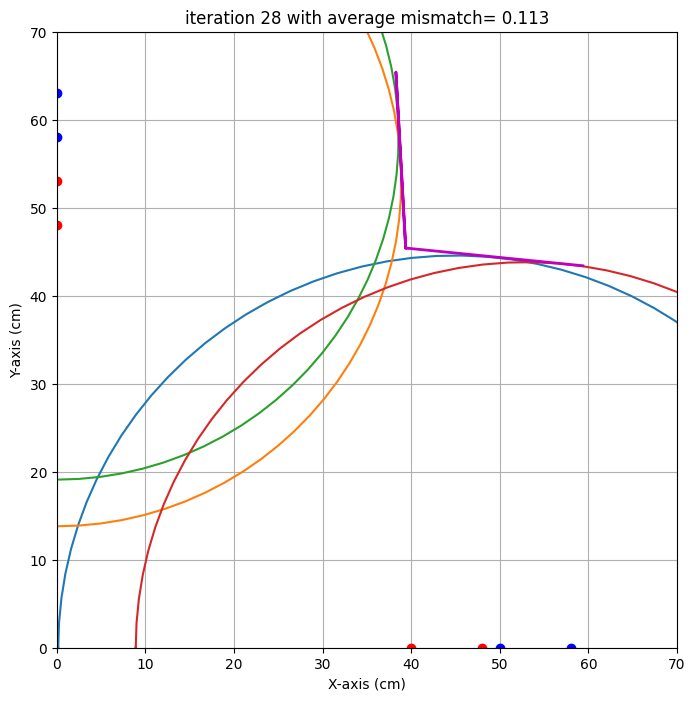

end iteration 28 with average mismatch= 0.113
end iteration 29 with average mismatch= 0.103
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.101
###############################################################################
end of iteration  30
Best alpha=  -5.76 with uncertainty=   1.60
Best beta =  -3.18 with uncertainty=   4.69
Best x0   =  39.38 with uncertainty=   1.36
Best y0   =  45.41 with uncertainty=   0.53
###############################################################################


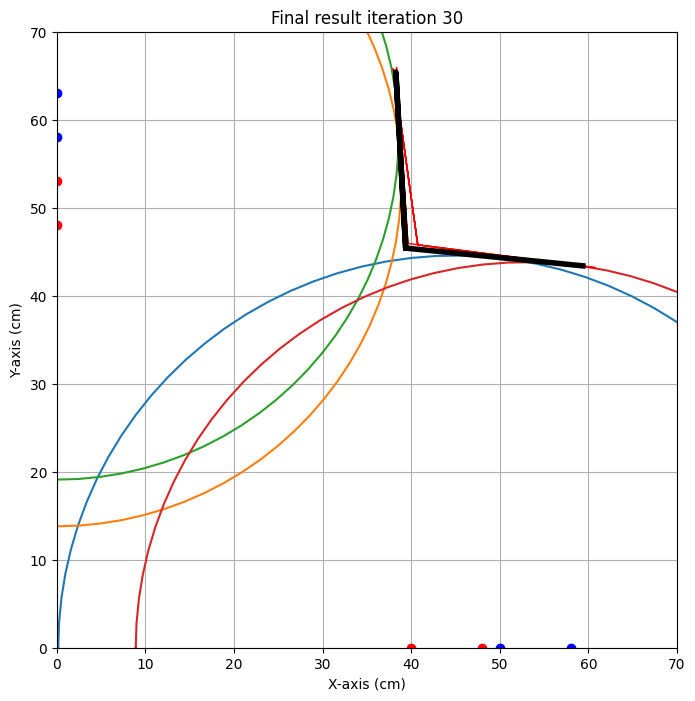

{'alpha': np.float64(-5.756230519076256), 'alpha_eps': np.float64(1.5958376092108173), 'beta': np.float64(-3.178134637342684), 'beta_eps': np.float64(4.68580572290027), 'x0': np.float64(39.376602809624345), 'x0_eps': np.float64(1.3649507208610459), 'y0': np.float64(45.41107058380378), 'y0_eps': np.float64(0.528265263896067)}
test locatie 
x0 target is : 40.0. Gevonden waarde: 39.4 cm met een standaardafwijking van 1.4 cm 
y0 target is : 45.0. Gevonden waarde: 45.4 cm met een standaardafwijking van 0.5 cm 
alpha target is : -8.0. Gevonden waarde: -5.8 graden met een standaardafwijking van 1.6 graad 
beta target is : -2.0. Gevonden waarde: -3.2 graden met een standaardafwijking van 4.7 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  40,
                    'y0':  45,
                    'alpha' :  -8,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0, 89.7],
                    [0, 48, 0, 58, 78.4],
                    [0, 53, 0, 63, 77.8],
                    [48, 0, 58, 0, 88.2]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

## leerdoel 1
#### algoritme [Christiaan]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="kris.jpeg" width="400">

<img src="iteratie_1.jpeg" width="400">

#### algoritme [Niels]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="niels.jpeg" width="400">

#### algoritme [Jelle]
Voeg een foto in van het algoritme van het derde groepslid
<img src="jelle.jpeg" width="400">

Figuur: ![Alt](iteratie_2.jpeg)
Figuur: ![Alt](iteratie_3.jpeg)


## leerdoel 2

In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  49,
           'y0': 49,
           'alpha' : 30,
           'beta' : 180,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'kris' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 0, 45, 170],
    [45,0 , 35,0, 69.58],
    [45,0, 55, 0, 99.3],
    [0,45, 0,35,98.2],
    [0,45, 0,35, 89.2]
    ]),
       'niels' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0, 162]
    [0, 50, 0, 60, 68.8], 
    [0, 40, 0, 50, 94],
    [35, 0, 40,0, 98],
    [20,0, 25,0, 97],
    [50,0,40,0,98.6]   
    ]),
       'jelle' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0, 34,0, 179],
    #[0,34, 0, 40, 140],
    [0,50,0,56,62],
    [0,60, 0,56, 63],
    [50,0,59,0, 108],
    [40,0,64,0, 148]

    ])
      }

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  84.5
1   0  45   0  55  68.6
2   0  50   0  60  69.3
3  38   0  48   0  84.2


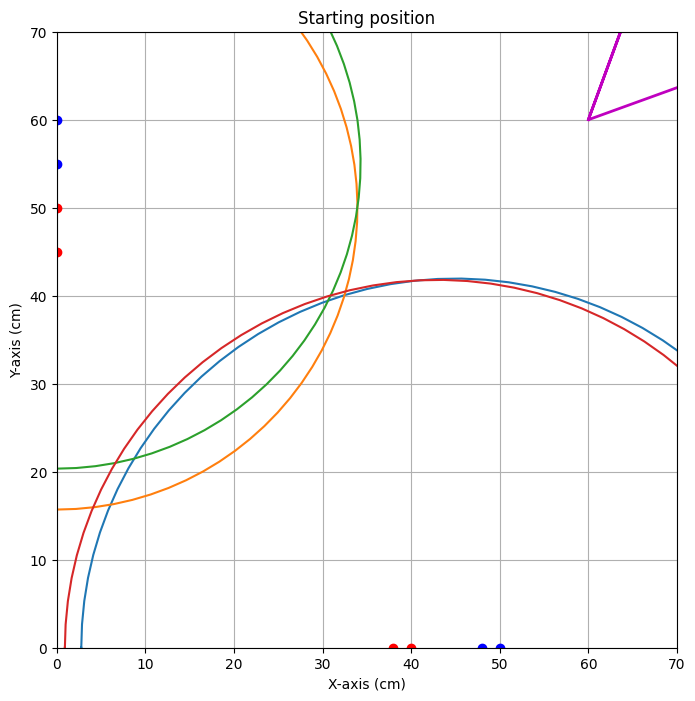


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.318


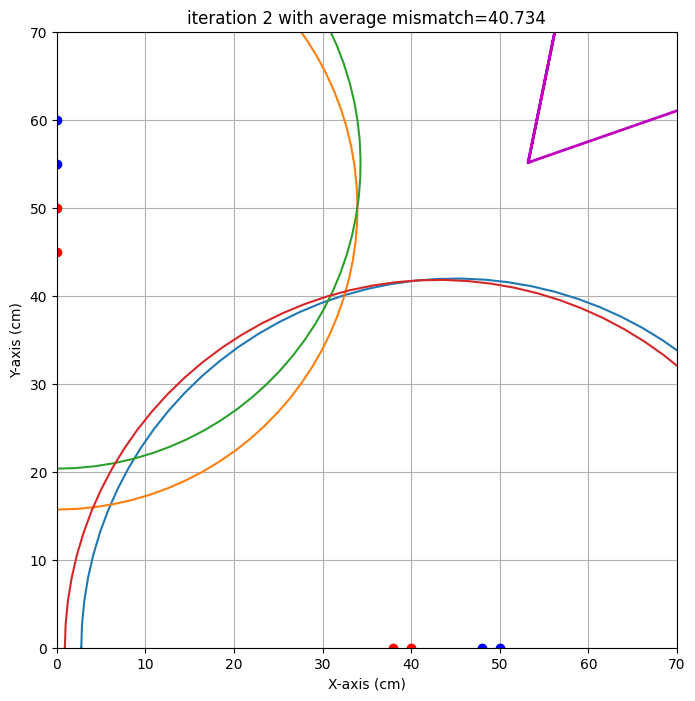

end iteration 2 with average mismatch=40.734


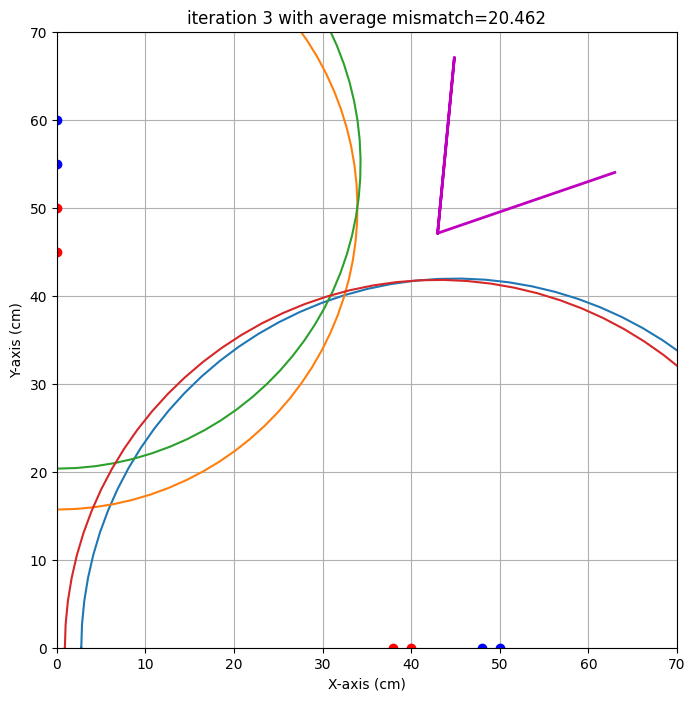

end iteration 3 with average mismatch=20.462


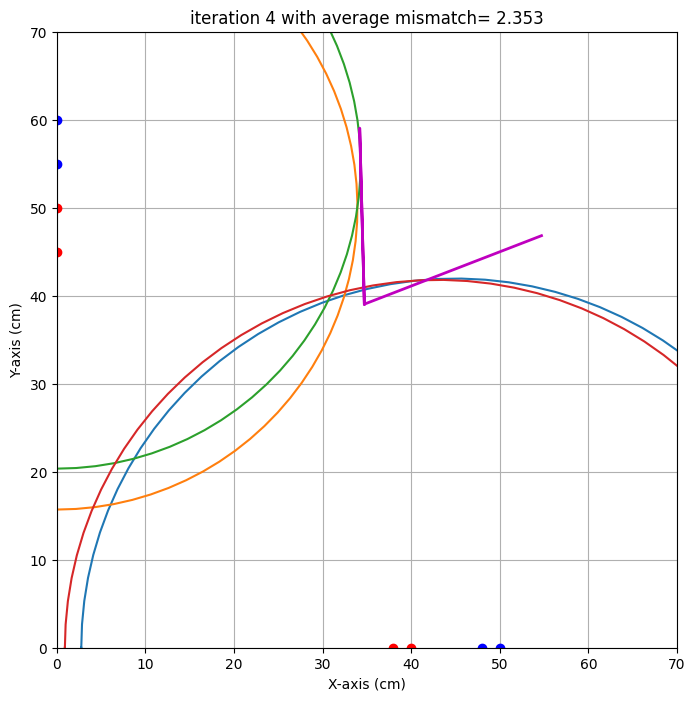

end iteration 4 with average mismatch= 2.353


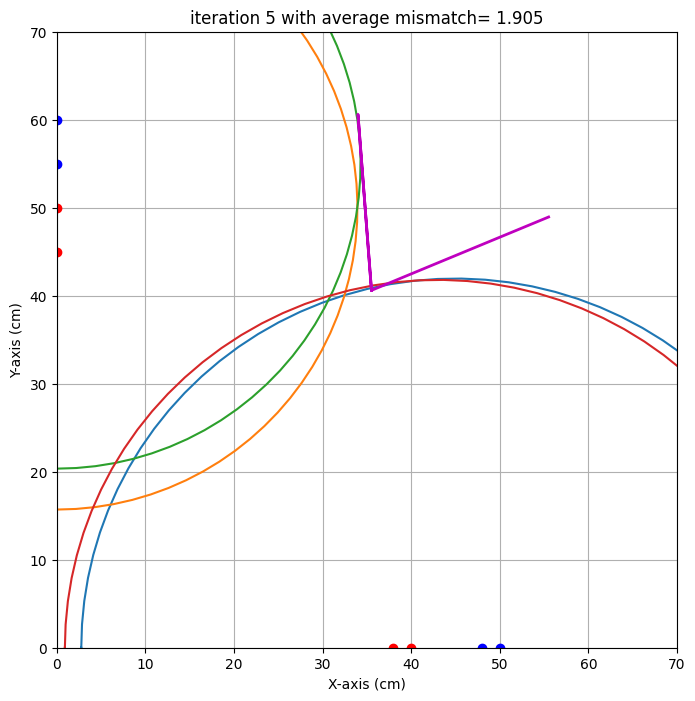

end iteration 5 with average mismatch= 1.905
end iteration 6 with average mismatch= 1.877


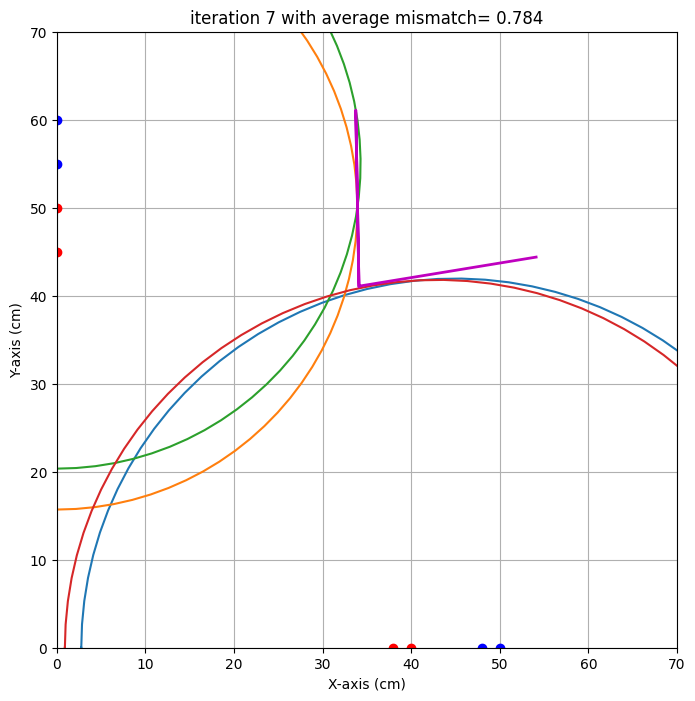

end iteration 7 with average mismatch= 0.784


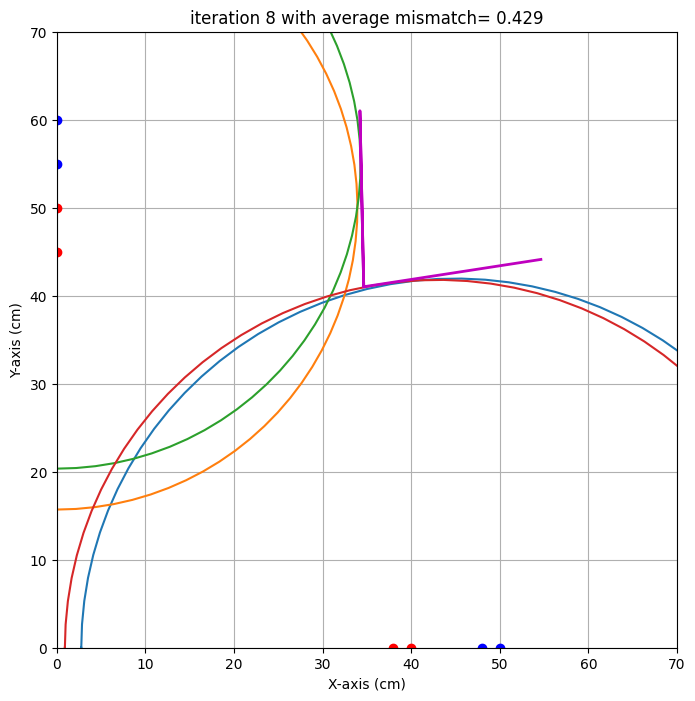

end iteration 8 with average mismatch= 0.429
end iteration 9 with average mismatch= 0.409
end iteration 10 with average mismatch= 0.401
end iteration 11 with average mismatch= 0.398


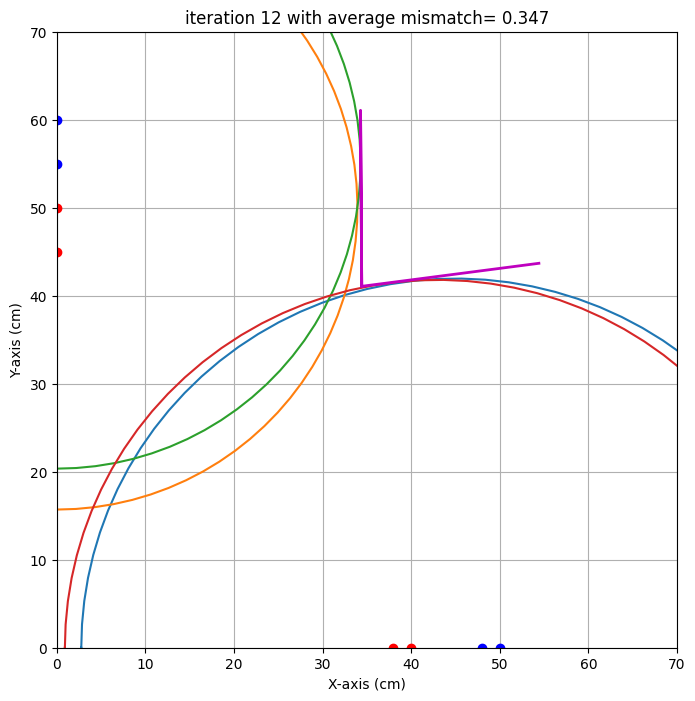

end iteration 12 with average mismatch= 0.347


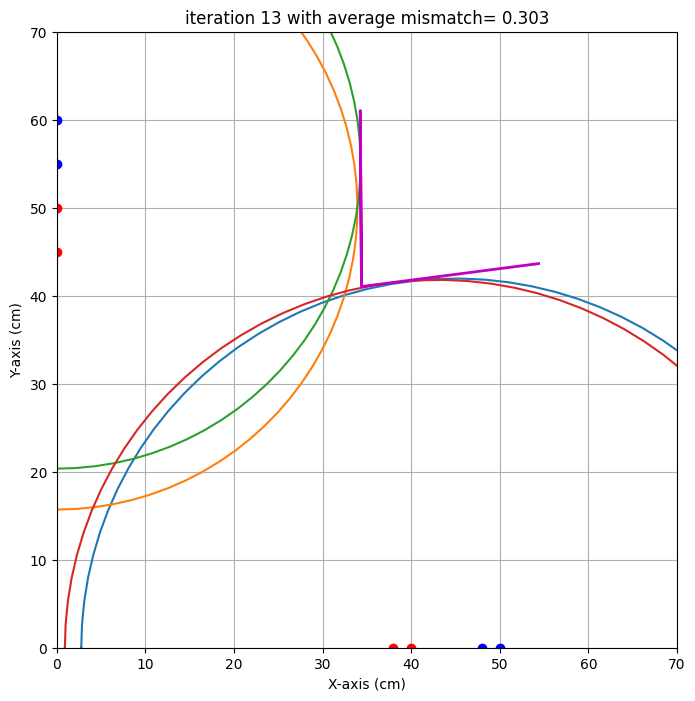

end iteration 13 with average mismatch= 0.303
end iteration 14 with average mismatch= 0.298
end iteration 15 with average mismatch= 0.298
end iteration 16 with average mismatch= 0.297
end iteration 17 with average mismatch= 0.297
end iteration 18 with average mismatch= 0.297
end iteration 19 with average mismatch= 0.285
end iteration 20 with average mismatch= 0.274
end iteration 21 with average mismatch= 0.274


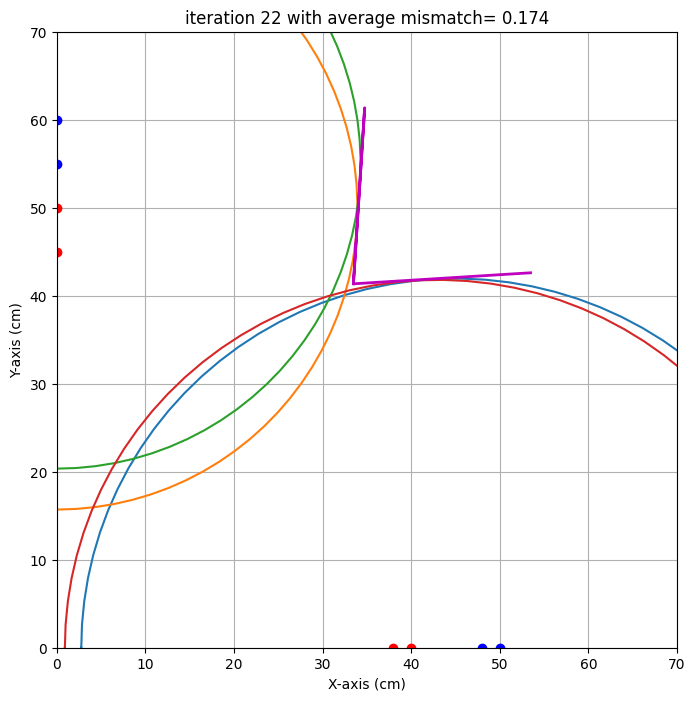

end iteration 22 with average mismatch= 0.174
end iteration 23 with average mismatch= 0.169
end iteration 24 with average mismatch= 0.168
end iteration 25 with average mismatch= 0.168
end iteration 26 with average mismatch= 0.167
end iteration 27 with average mismatch= 0.167
end iteration 28 with average mismatch= 0.167
end iteration 29 with average mismatch= 0.167
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.167
###############################################################################
end of iteration  30
Best alpha=   3.58 with uncertainty=  10.73
Best beta =   3.64 with uncertainty=   4.45
Best x0   =  33.47 with uncertainty=   1.02
Best y0   =  41.35 with uncertainty=   2.35
###############################################################################


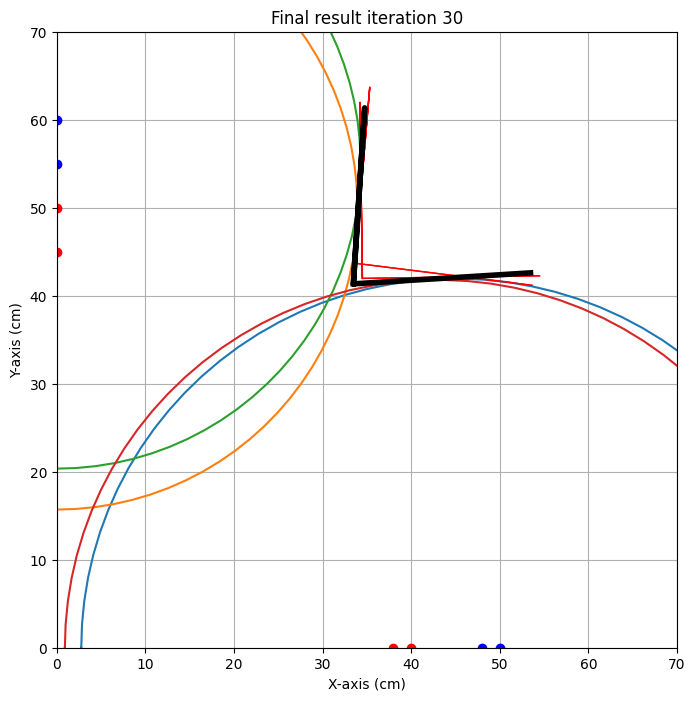

{'alpha': np.float64(3.579794088222383), 'alpha_eps': np.float64(10.728189349611435), 'beta': np.float64(3.6445544328229196), 'beta_eps': np.float64(4.448646148496967), 'x0': np.float64(33.471724084021766), 'x0_eps': np.float64(1.0196473776109016), 'y0': np.float64(41.34769856957846), 'y0_eps': np.float64(2.3463998336534715)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  92.3
1   0  50   0  60  68.0
2   0  55   0  65  65.7
3  45   0  55   0  91.7


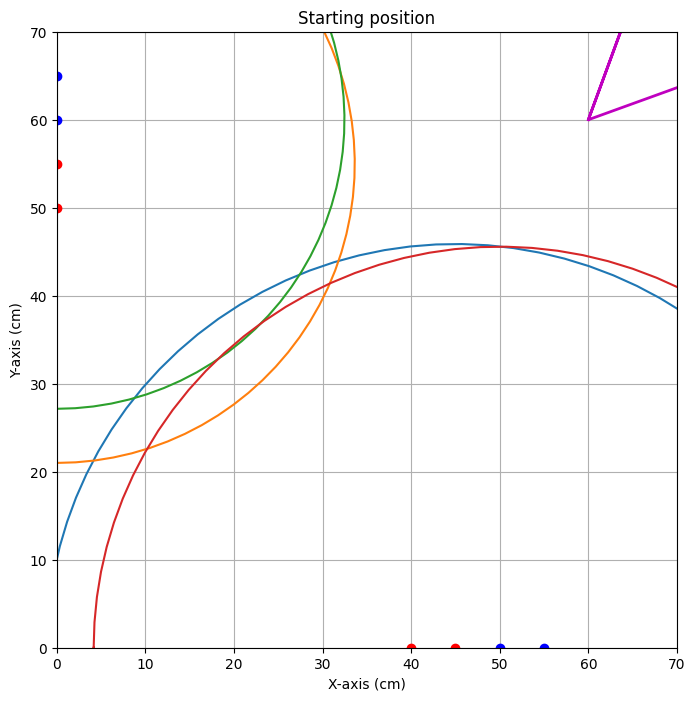


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.004


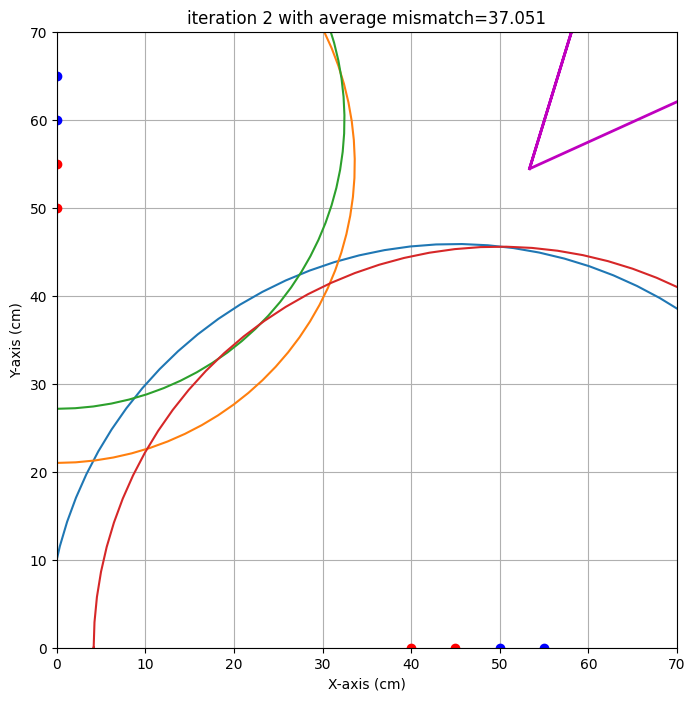

end iteration 2 with average mismatch=37.051


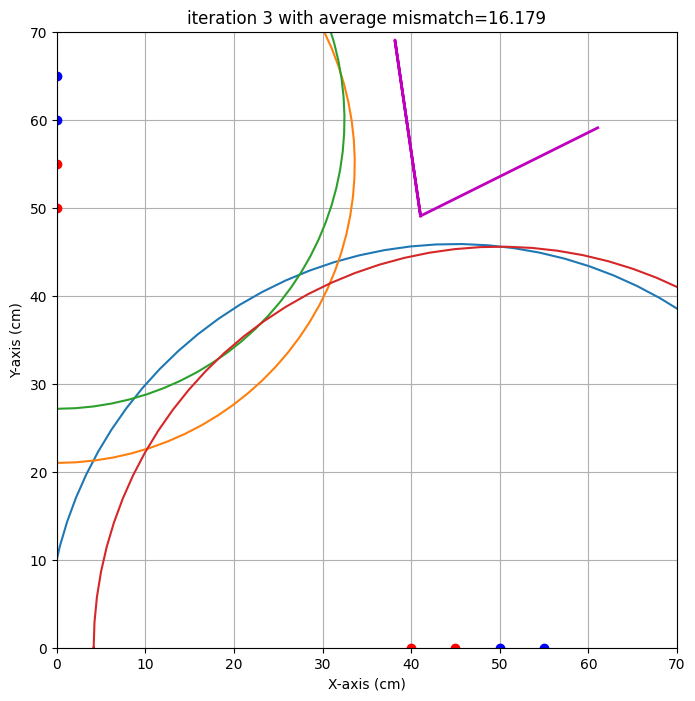

end iteration 3 with average mismatch=16.179


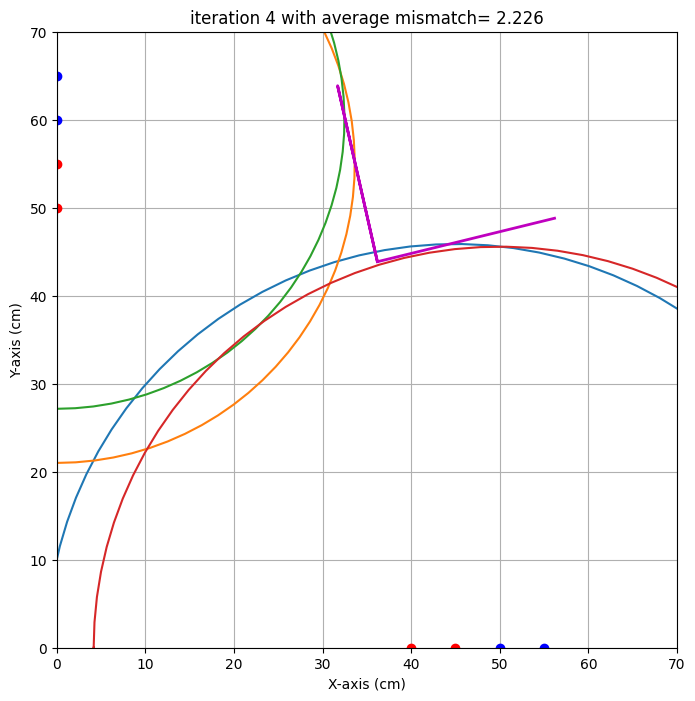

end iteration 4 with average mismatch= 2.226


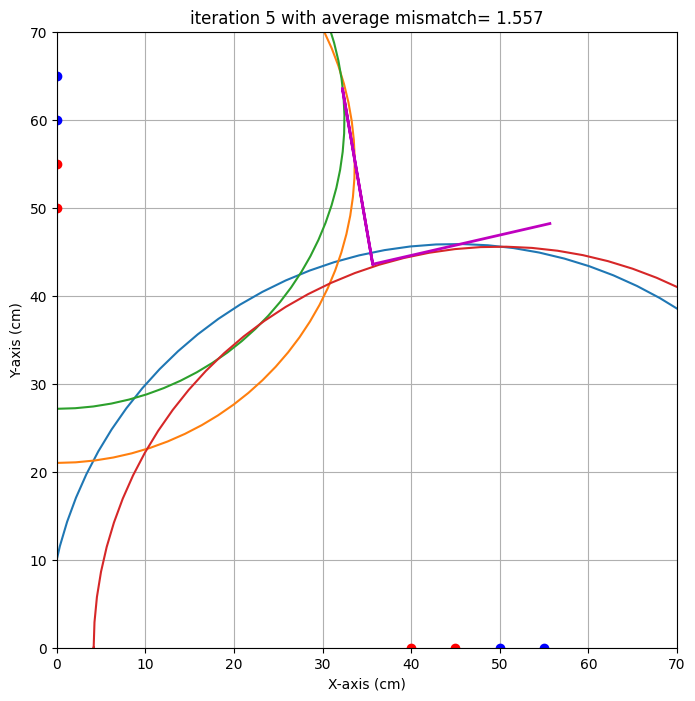

end iteration 5 with average mismatch= 1.557
end iteration 6 with average mismatch= 1.550
end iteration 7 with average mismatch= 1.550


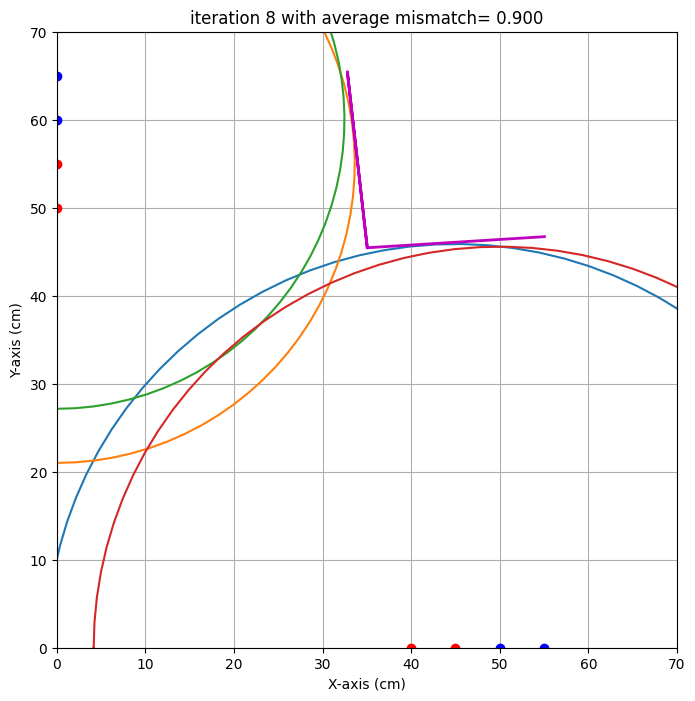

end iteration 8 with average mismatch= 0.900
end iteration 9 with average mismatch= 0.869
end iteration 10 with average mismatch= 0.859
end iteration 11 with average mismatch= 0.859
end iteration 12 with average mismatch= 0.859


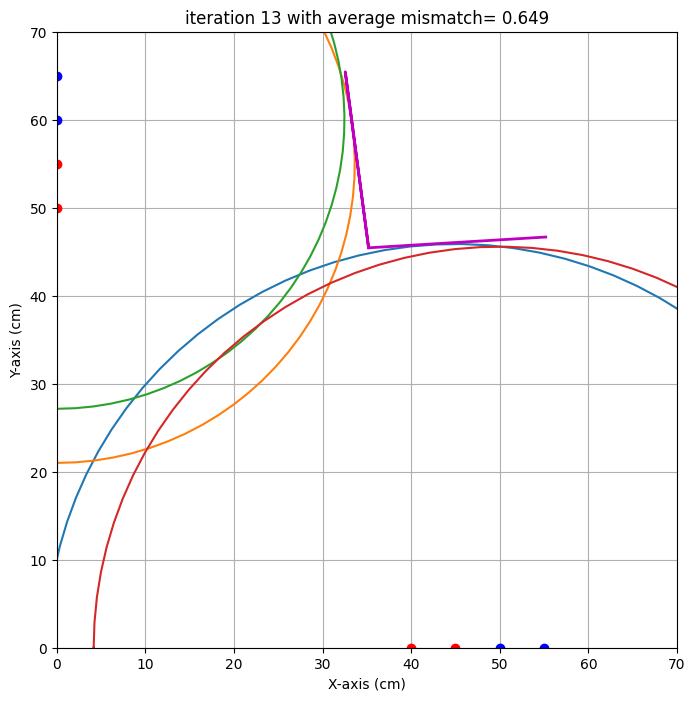

end iteration 13 with average mismatch= 0.649
end iteration 14 with average mismatch= 0.638
end iteration 15 with average mismatch= 0.637
end iteration 16 with average mismatch= 0.636
end iteration 17 with average mismatch= 0.626


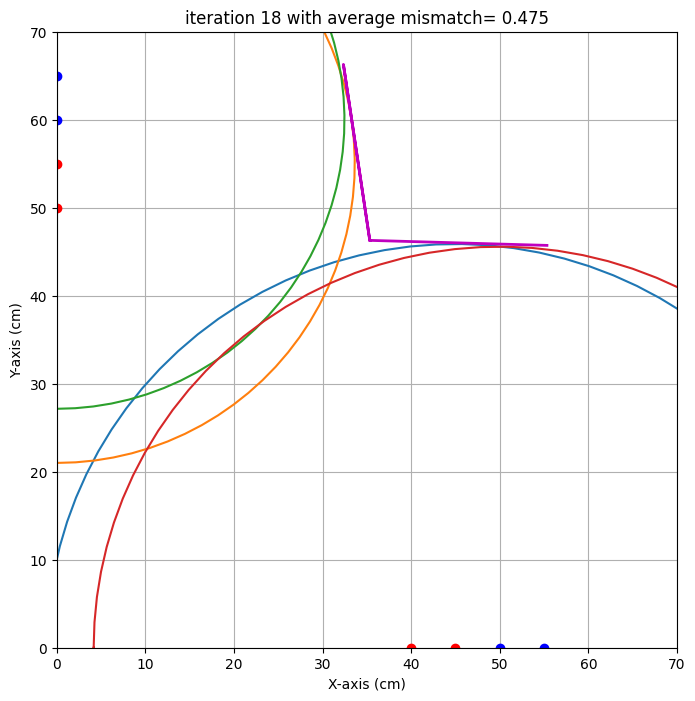

end iteration 18 with average mismatch= 0.475
end iteration 19 with average mismatch= 0.433


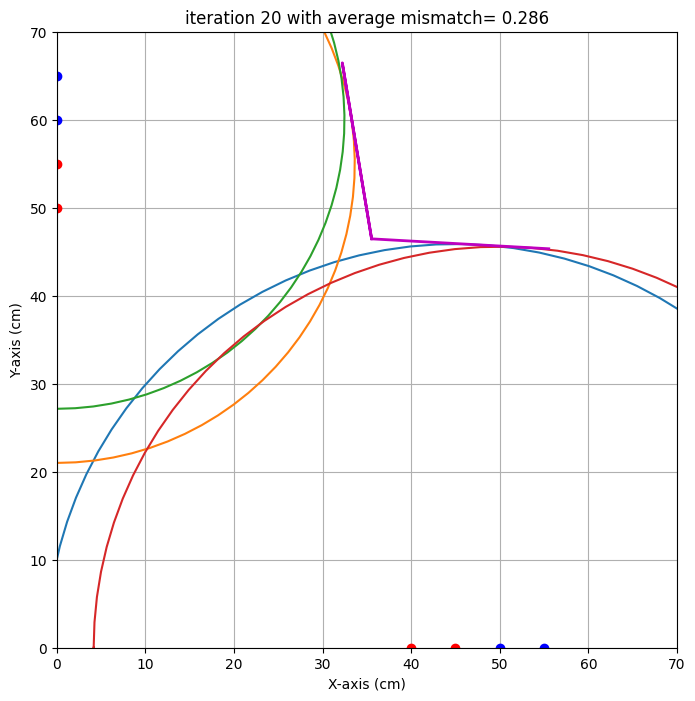

end iteration 20 with average mismatch= 0.286
end iteration 21 with average mismatch= 0.284
end iteration 22 with average mismatch= 0.283
end iteration 23 with average mismatch= 0.282
end iteration 24 with average mismatch= 0.282
end iteration 25 with average mismatch= 0.282
end iteration 26 with average mismatch= 0.282
end iteration 27 with average mismatch= 0.282
end iteration 28 with average mismatch= 0.282
end iteration 29 with average mismatch= 0.282
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.282
###############################################################################
end of iteration  30
Best alpha=  -3.23 with uncertainty=   5.31
Best beta =  -9.40 with uncertainty=   6.60
Best x0   =  35.53 with uncertainty=   1.51
Best y0   =  46.46 with uncertainty=   1.50
###############################################################################


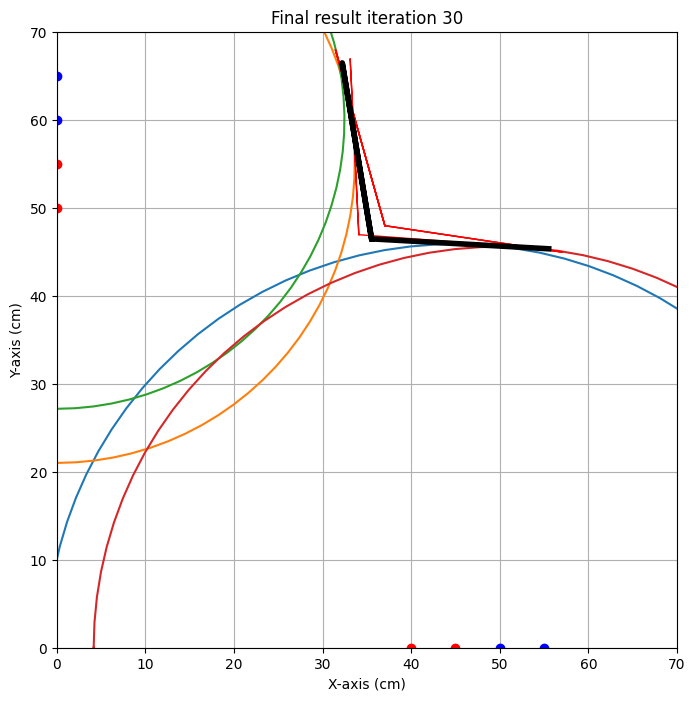

{'alpha': np.float64(-3.227338912209941), 'alpha_eps': np.float64(5.310411295757735), 'beta': np.float64(-9.404533304023735), 'beta_eps': np.float64(6.600113039219299), 'x0': np.float64(35.5250071288809), 'x0_eps': np.float64(1.50569964072006), 'y0': np.float64(46.46130805411957), 'y0_eps': np.float64(1.4955809341910893)}
locatie 1 
x0 target is : 35.0. Gevonden waarde: 33.5 cm met een standaardafwijking van 1.0 cm 
y0 target is : 40.0. Gevonden waarde: 41.3 cm met een standaardafwijking van 2.3 cm 
alpha target is : 20.0. Gevonden waarde: 3.6 graden met een standaardafwijking van 10.7 graad 
beta target is : 10.0. Gevonden waarde: 3.6 graden met een standaardafwijking van 4.4 graad 

locatie 2 
x0 target is : 36.0. Gevonden waarde: 35.5 cm met een standaardafwijking van 1.5 cm 
y0 target is : 46.0. Gevonden waarde: 46.5 cm met een standaardafwijking van 1.5 cm 
alpha target is : 9.0. Gevonden waarde: -3.2 graden met een standaardafwijking van 5.3 graad 
beta target is : 3.0. Gevonden 

In [14]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35,
                    'y0':40,
                    'alpha' : 20,
                    'beta' : 10,},
           'locatie 2':{'x0': 36,
                    'y0':46,
                    'alpha' : 9,
                    'beta' : 3}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,84.5],
    [0,45, 0,55,68.6],
    [0,50, 0, 60, 69.3],
    [38,0, 48, 0, 84.2]

    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 50, 0, 92.3],
    [0,50, 0,60, 68],
    [0,55, 0,65, 65.7],
    [45, 0, 55, 0, 91.7]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))